In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# breaking

In [2]:
# load data
from scipy.optimize import curve_fit
from superconductivity.utilities.functions.upsampling import upsample
from mar_fit import prepare_mar_trace


def linear(x, a, b):
    return +a * x + b


Vbias = np.linspace(-0.5, 4.5, 251)
Ibias = np.linspace(-0.5, 4.5, 251)

plateau = "abcdde"
regions = "abcdef"
channels = ["7", "6", "3", "3-2", "2", "1"]
i_skip = [0, 9, 19, 71, 206, 262]
ii = [0, 13, 30, 83, 200, 230]

datafit = np.load("breaking/fit_data.npz", allow_pickle=True)
dataeva = np.load("breaking/eva.npz", allow_pickle=True)
datasim = np.load("breaking/sim.npz", allow_pickle=True)
datatun = np.load("breaking/tunnel_eva.npz")

Vtunnel_mV = datatun["Vbias_mV"]
Itunnelup_nA = datatun["Iup_nA"]
Itunneldown_nA = datatun["Idown_nA"]
xtunnel_arbu = datatun["x_arbu"]

xtunnel_arbu -= xtunnel_arbu[0]
dGtunnel_G0 = np.gradient(Itunnelup_nA, Vtunnel_mV, axis=-1) / sc.G0_muS
GNtunnel_G0 = np.nanmean(dGtunnel_G0, axis=-1)
lnGNtunnel_G0 = np.log(GNtunnel_G0)
validtunnel = np.isfinite(lnGNtunnel_G0)
(m, c), pcov = curve_fit(
    linear,
    xtunnel_arbu[validtunnel],
    lnGNtunnel_G0[validtunnel],
    # p0=(-0.01, -8),
)
kappa_AA = 1.05  # nm
alpha_x_AA = np.abs(m) / (kappa_AA)  # AA/arbu

x_arbu = datafit["x_arbu"]
Vbias0_mV = datafit["V_mV"]
Iexp0_nA = dataeva["Iup_nA"]
Ifit0_nA = datafit["Ifit_nA"]
Isim0_nA = datasim["Isim_nA"]

taus = datafit["tau"]
GN_G0 = datafit["GN_G0"]
Delta_meV = datafit["Delta_meV"]
sigmaV_mV = datafit["sigmaV_mV"]
Delta0_meV = 0.1885

Vbias0 = Vbias0_mV / Delta0_meV
x_AA = alpha_x_AA * (x_arbu - x_arbu[262])
xtunnel_AA = alpha_x_AA * xtunnel_arbu
Ifit0 = Ifit0_nA / (Delta0_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
Iexp0 = Iexp0_nA / (Delta0_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
Isim0 = datasim["Isim"]
# taus[taus == 0.0] = np.nan
# taus[taus == 0.001] = 0

Ifit = np.full((len(x_arbu), Vbias.shape[0]), np.nan)
Iexp = np.full((len(x_arbu), Vbias.shape[0]), np.nan)
Isim = np.full((len(x_arbu), Vbias.shape[0]), np.nan)

Vfit = np.full((len(x_arbu), Ibias.shape[0]), np.nan)
Vexp = np.full((len(x_arbu), Ibias.shape[0]), np.nan)
Vsim = np.full((len(x_arbu), Ibias.shape[0]), np.nan)

for i, xi_arbu in enumerate(x_arbu):

    maskfit = np.isfinite(Ifit0[i, :])
    if np.sum(maskfit) > 2:
        Ifit[i, :] = sc.nanbin_y_over_x(
            upsample(Ifit0[i, maskfit], axis=-1),
            upsample(Vbias0[maskfit], axis=-1),
            Vbias,
        )
        Vfit[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[maskfit], axis=-1),
            upsample(Ifit0[i, maskfit], axis=-1),
            Ibias,
        )

    maskexp = np.isfinite(Iexp0[i, :])
    if np.sum(maskexp) > 2:
        Iexp[i, :] = sc.nanbin_y_over_x(
            upsample(Iexp0[i, maskexp], axis=-1),
            upsample(Vbias0[maskexp], axis=-1),
            Vbias,
        )

        Vexp[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[maskexp], axis=-1),
            upsample(Iexp0[i, maskexp], axis=-1),
            Ibias,
        )

    masksim = np.isfinite(Isim0[i, :])
    if np.sum(masksim) > 2:
        Isim[i, :] = sc.nanbin_y_over_x(
            upsample(Isim0[i, masksim], axis=-1),
            upsample(Vbias0[masksim], axis=-1),
            Vbias,
        )

        Vsim[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[masksim], axis=-1),
            upsample(Isim0[i, masksim], axis=-1),
            Ibias,
        )

dGexp = np.gradient(Iexp, Vbias, axis=-1)
dGfit = np.gradient(Ifit, Vbias, axis=-1)
dGsim = np.gradient(Isim, Vbias, axis=-1)

dRexp = np.gradient(Vexp, Ibias, axis=-1)
dRfit = np.gradient(Vfit, Ibias, axis=-1)
dRsim = np.gradient(Vsim, Ibias, axis=-1)

/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_89977/1583992315.py:33: RuntimeWarning: invalid value encountered in log
  lnGNtunnel_G0 = np.log(GNtunnel_G0)
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_89977/1583992315.py:59: RuntimeWarning: invalid value encountered in divide
  Ifit0 = Ifit0_nA / (Delta0_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_89977/1583992315.py:60: RuntimeWarning: divide by zero encountered in divide
  Iexp0 = Iexp0_nA / (Delta0_meV * GN_G0[:, np.newaxis] * sc.G0_muS)


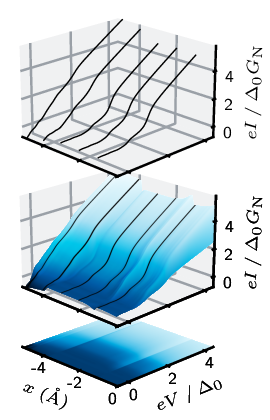

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/breaking/cal_iv/main.png

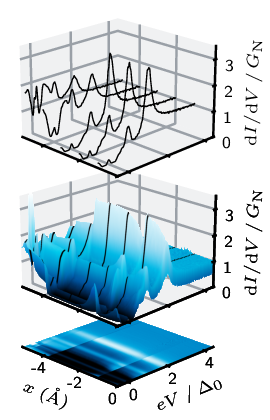

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/breaking/cal_didv/main.png

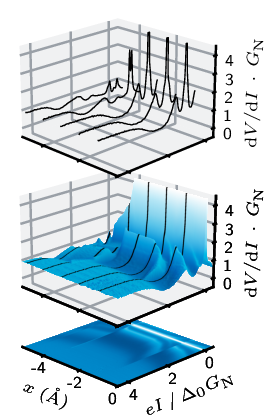

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/breaking/cal_dvdi/main.png

In [3]:
# cal
from superconductivity.visuals.landscape import export_landscape_thesis

exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=x_AA,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    Alabel="$x\\ (\\mathring{\\mathrm{A}})$",
    waterfall_traces=[-5, -4, -3, -2, -1],
    name="cal",
    sub_dir=f"atomic_contact/breaking/",
    surface_points=(300, 100),
    surface_center_width_y=0,
    Vbiaslim=(-0.5, 4.5),
    Ibiaslim=(-0.5, 4.5),
    Abiaslim=(-5.25, 0),
    Iticks=[0, 2, 4],
    Ilim=(-0.75, 5.75),
    dGlim=(0, 3.5),
    dRlim=(-0.5, 4.5),
)

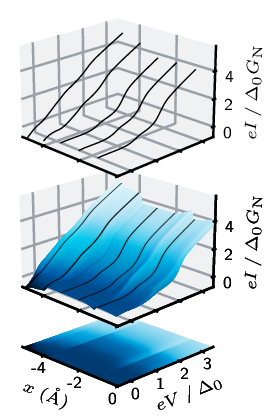

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/breaking/sim_iv/main.png

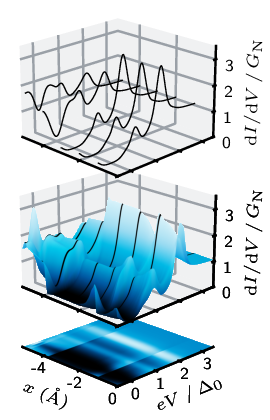

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/breaking/sim_didv/main.png

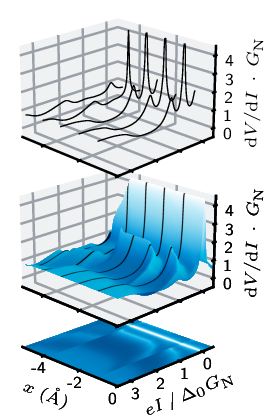

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/breaking/sim_dvdi/main.png

In [4]:
# sim
from superconductivity.visuals.landscape import export_landscape_thesis

exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=x_AA,
    Ibias=Ibias,
    Iexp=Isim,
    dGexp=dGsim,
    dRexp=dRsim,
    Alabel="$x\\ (\\mathring{\\mathrm{A}})$",
    waterfall_traces=[-5, -4, -3, -2, -1],
    name="sim",
    sub_dir=f"atomic_contact/breaking/",
    surface_points=(300, 100),
    surface_center_width_y=0,
    Vbiaslim=(-0.5, 3.5),
    Ibiaslim=(-0.5, 3.5),
    Abiaslim=(-5.25, 0),
    Iticks=[0, 2, 4],
    Ilim=(-0.75, 5.75),
    dGlim=(0, 3.5),
    dRlim=(-0.5, 4.5),
)

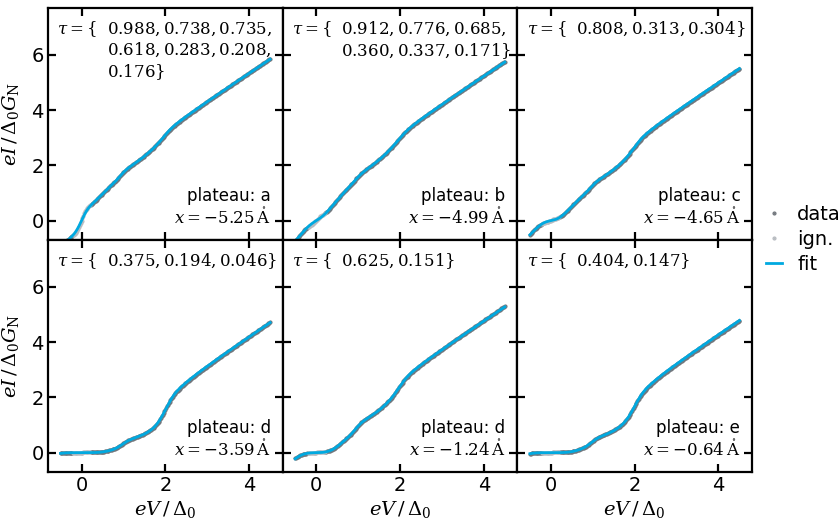

In [5]:
# ivs
fig, axes = sc.get_figures(
    figsize=(4.2, 2.6),
    padding=(0.2, 0.2, 0.4, 0.0),
    nrows=2,
    ncols=3,
)

j = 0
for i, xi_AA in enumerate(x_AA):
    if i in ii:
        # if True:
        mask = prepare_mar_trace(
            Vbias * Delta0_meV,
            Iexp[i, :],
            Vnan_mV=0.04,
        )
        not_mask = np.logical_not(mask)
        axes[j].plot(Vbias[mask], Iexp[i, mask], ".", color=sc.seegrau100, zorder=0)
        axes[j].plot(
            Vbias[not_mask],
            Iexp[i, not_mask],
            ".",
            color=sc.seegrau35,
            zorder=0,
        )
        axes[j].plot(
            # np.where(mask, Vbias, np.nan),
            # np.where(mask, Ifit[i, :], np.nan),
            Vbias,
            Ifit[i, :],
            "-",
            color=sc.seeblau100,
            zorder=1,
        )

        taustring = "$\\tau=\\{$"
        axes[j].text(
            0.04,
            0.95,
            taustring,
            transform=axes[j].transAxes,
            ha="left",
            va="top",
            size=6,
        )
        k = 0
        taustring = "$"
        for taui in taus[i, :]:
            if np.logical_and(np.isfinite(taui), taui > 0.001):
                if k % 3 == 0 and k > 0:
                    taustring += "$\n$"
                taustring += f"{taui:.3f}, "
                k += 1
        taustring = taustring[:-2] + "\\}$"
        axes[j].text(
            0.25,
            0.95,
            taustring,
            transform=axes[j].transAxes,
            ha="left",
            va="top",
            size=6,
        )
        axes[j].text(
            0.95,
            0.05,
            f"$x = {xi_AA:.2f}$" + "$\\,\\mathring{\\mathrm{A}}$",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].text(
            0.95,
            0.15,
            f"plateau: {plateau[j]}",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].set_xlim(-0.8, 4.8)
        axes[j].set_ylim(-0.7, 7.7)
        j += 1

axes[5].plot([], [], ".", color=sc.seegrau100, label="data")
axes[5].plot([], [], ".", color=sc.seegrau35, label="ign.")
axes[5].plot([], [], "-", color=sc.seeblau100, label="fit")

axes[5].legend(
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.01, 1.2),
)

axes = sc.daumenkino_layout(
    fig,
    axes,
    title="atomic_contact/breaking/ivs",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eI\\,/\\,\\Delta_0 G_\\mathrm{N}$",
    xticks=[0, 2, 4],
    yticks=[0, 2, 4, 6],
)
plt.show()

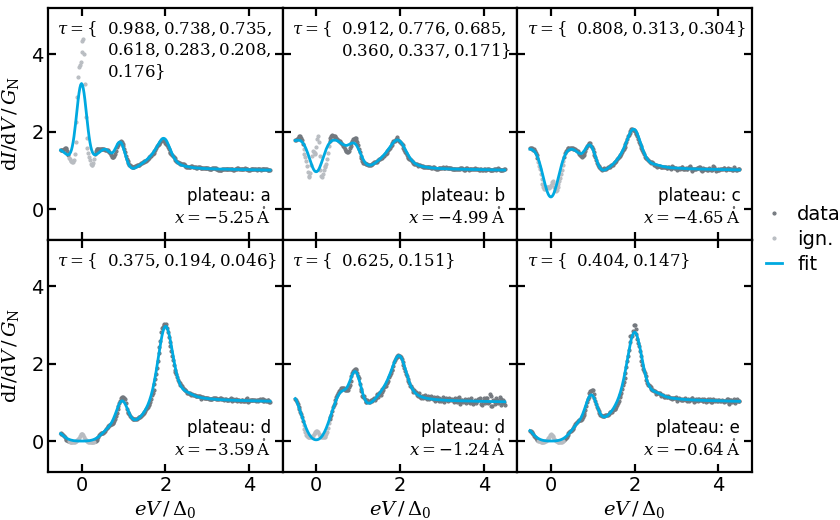

In [6]:
# didvs
fig, axes = sc.get_figures(
    figsize=(4.2, 2.6),
    padding=(0.2, 0.2, 0.4, 0.0),
    nrows=2,
    ncols=3,
)

j = 0
for i, xi_AA in enumerate(x_AA):
    if i in ii:
        # if True:
        mask = prepare_mar_trace(
            Vbias * Delta0_meV,
            Iexp[i, :],
            Vnan_mV=0.06,
        )
        not_mask = np.logical_not(mask)
        axes[j].plot(Vbias[mask], dGexp[i, mask], ".", color=sc.seegrau100, zorder=0)
        axes[j].plot(
            Vbias[not_mask], dGexp[i, not_mask], ".", color=sc.seegrau35, zorder=0
        )
        axes[j].plot(
            # np.where(mask, Vbias, np.nan),
            # np.where(mask, dGfit[i, :], np.nan),
            Vbias,
            dGfit[i, :],
            "-",
            color=sc.seeblau100,
            zorder=1,
        )

        taustring = "$\\tau=\\{$"
        axes[j].text(
            0.04,
            0.95,
            taustring,
            transform=axes[j].transAxes,
            ha="left",
            va="top",
            size=6,
        )
        k = 0
        taustring = "$"
        for taui in taus[i, :]:
            if np.logical_and(np.isfinite(taui), taui > 0.001):
                if k % 3 == 0 and k > 0:
                    taustring += "$\n$"
                taustring += f"{taui:.3f}, "
                k += 1
        taustring = taustring[:-2] + "\\}$"
        axes[j].text(
            0.25,
            0.95,
            taustring,
            transform=axes[j].transAxes,
            ha="left",
            va="top",
            size=6,
        )
        axes[j].text(
            0.95,
            0.05,
            f"$x = {xi_AA:.2f}$" + "$\\,\\mathring{\\mathrm{A}}$",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].text(
            0.95,
            0.15,
            f"plateau: {plateau[j]}",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].set_xlim(-0.8, 4.8)
        axes[j].set_ylim(-0.8, 5.2)
        j += 1


axes[5].plot([], [], ".", color=sc.seegrau100, label="data")
axes[5].plot([], [], ".", color=sc.seegrau35, label="ign.")
axes[5].plot([], [], "-", color=sc.seeblau100, label="fit")

axes[5].legend(
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.01, 1.2),
)

axes = sc.daumenkino_layout(
    fig,
    axes,
    title="atomic_contact/breaking/didvs",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel=r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{N}$",
    xticks=[0, 2, 4],
    yticks=[0, 2, 4],
)
plt.show()

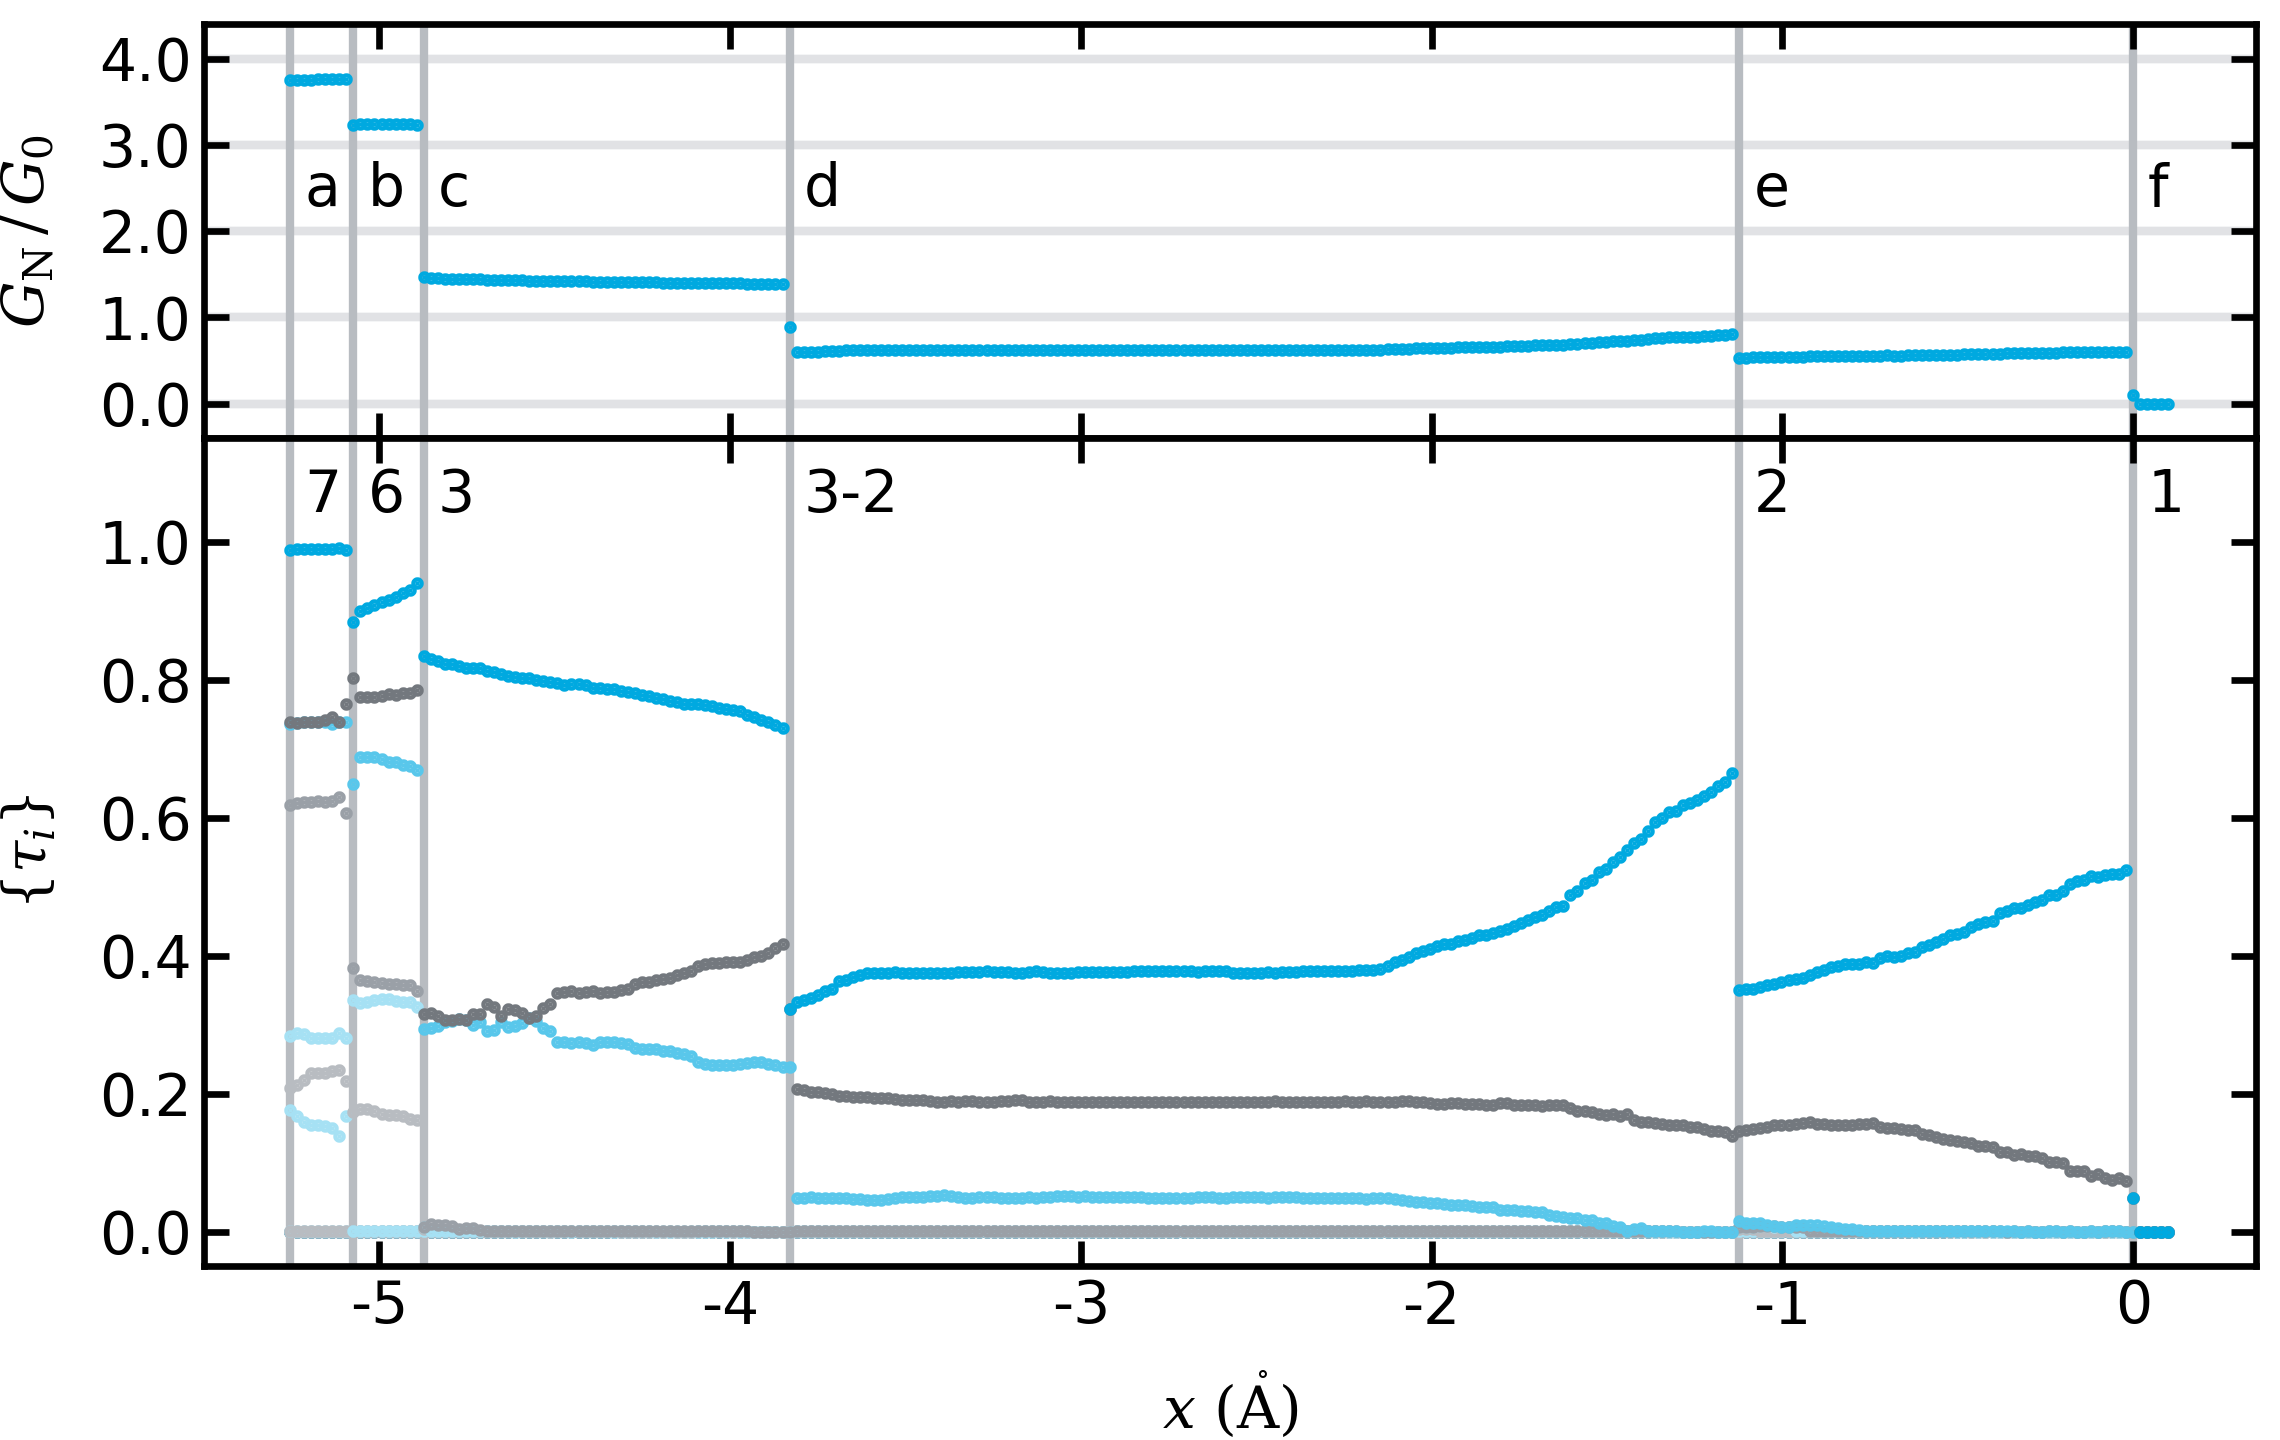

In [54]:
# pincode

colors = [
    # sc.seeblau120,
    # sc.seegrau120,
    sc.seeblau100,
    sc.seegrau100,
    # sc.seeblau80,
    # sc.seegrau80,
    sc.seeblau65,
    sc.seegrau65,
    sc.seeblau35,
    sc.seegrau35,
    sc.seeblau35,
    sc.seegrau35,
    sc.seeblau35,
    sc.seegrau35,
]
fig, axes = sc.get_figures(
    figsize=(3.8, 2.4),
    padding=(0.3, 0.25, 0.0, 0.0),
    nrows=2,
    ncols=1,
    height_ratios=[1, 2],
)
axes[0].plot(x_AA, GN_G0, ".", color=sc.seeblau100, label="$G_\\mathrm{N}\\,/\\,G_0$")

for i in range(12):
    axes[1].plot(
        x_AA,
        taus[:, i],
        ".",
        color=colors[i % 10],
        zorder=-i,
    )

axes[0].set_ylim((-0.4, 4.4))
axes[1].set_ylim((-0.05, 1.15))

for j, i in enumerate(i_skip):
    for ax in axes:
        ylim = ax.get_ylim()
        ax.vlines(x_AA[i], *ylim, color=sc.seegrau35, zorder=-10)
    axes[0].text(
        x_AA[i] + 0.04,
        2.15,
        regions[j],
        ha="left",
        va="bottom",
        size=7,
    )
    axes[1].text(
        x_AA[i] + 0.04,
        1.025,
        channels[j],
        ha="left",
        va="bottom",
        size=7,
    )

xlim = -5.5, 0.35
for ax in axes:
    ax.set_xlim(xlim)
    for x_i in [0, 1, 2, 3, 4]:
        axes[0].hlines(x_i, *xlim, color=sc.seegrau20, zorder=-20)
axes = sc.daumenkino_layout(
    fig,
    axes,
    title="atomic_contact/breaking/pincode",
    xlabel="$x\\ (\mathring{\mathrm{A}})$",
    ylabel=[r"$G_\mathrm{N}\,/\,G_0$", r"$\{\tau_i\}$"],
    # xticks=[-2, -1, 0],
    yticks=[(0, 1, 2, 3, 4), (0, 0.2, 0.4, 0.6, 0.8, 1)],
    yticklabels=[
        (
            "0.0",
            "1.0",
            "2.0",
            "3.0",
            "4.0",
        ),
        ("0.0", "0.2", "0.4", "0.6", "0.8", "1.0"),
    ],
)
plt.show()

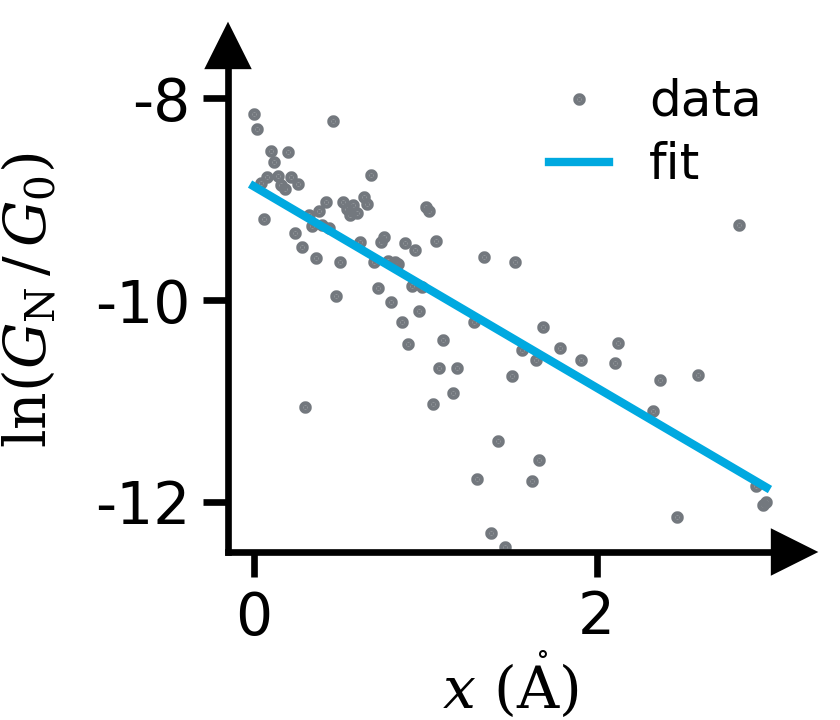

In [55]:
# tunneling
fig, ax = sc.get_figure(
    figsize=(1.4, 1.2),
    padding=(0.3, 0.2),
)
ax.plot(xtunnel_AA, lnGNtunnel_G0, ".", color=sc.seegrau100, label="data")
ax.plot(
    xtunnel_AA,
    linear(xtunnel_AA, -1, c),
    "-",
    color=sc.seeblau100,
    label="fit",
)
ax.set_ylim(-12.5, -7.5)

ax.legend(
    handlelength=1.2,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax = sc.theory_layout(
    fig,
    ax,
    title="atomic_contact/breaking/tunneling",
    xlabel="$x\\ (\\mathring{\\mathrm{A}})$",
    ylabel=r"$\mathrm{ln}\left(G_\mathrm{N}\,/\,G_0\right)$",
)
plt.show()

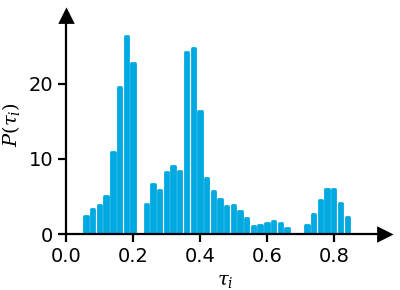

In [9]:
# histogram
temp = np.copy(taus[19:262, :3])
temp = np.ravel(temp)
indices = temp > 0.05
counts, bins = np.histogram(temp[indices], bins=100, range=(0, 1))
counts = np.array(counts, dtype=np.float64)

valid = counts != 0
# precounts = np.copy(counts)
counts0 = counts[0]
counts1 = counts[-1]
counts[0] = 0
counts[-1] = 0
counts = savgol_filter(counts, window_length=5, polyorder=0)
counts[0] = counts0
counts[-1] = counts1
# # counts = counts[5:]
# # counts = savgol_filter(counts, window_length=10, polyorder=0)
# # plt.plot(bins[5:-1], counts, ".")

tau_bins = np.linspace(0, 1, 100)
new_tau = np.linspace(0, 1.0, 51)
dtau = (new_tau[1] - new_tau[0]) / 4
counted = sc.nanbin_y_over_x(counts[valid], tau_bins[valid], new_tau)
sum_count = np.nansum(counted)

fig, ax = sc.get_figure(
    figsize=(2.0, 1.45),
    padding=(0.25, 0.2),
)
for i, tau_i in enumerate(new_tau):
    ax.fill_between(
        [tau_i - dtau, tau_i + dtau],
        y1=[0, 0],
        y2=[counted[i], counted[i]],
        color=sc.seeblau100,
    )
ax.set_ylim(0, 29)
ax.set_xlim(-0.0, 0.95)

ax = sc.theory_layout(
    fig,
    ax,
    title="atomic_contact/breaking/histogram",
    xlabel="$\\tau_i$",
    ylabel="$P\\left(\\tau_i\\right)$",
)
plt.show()

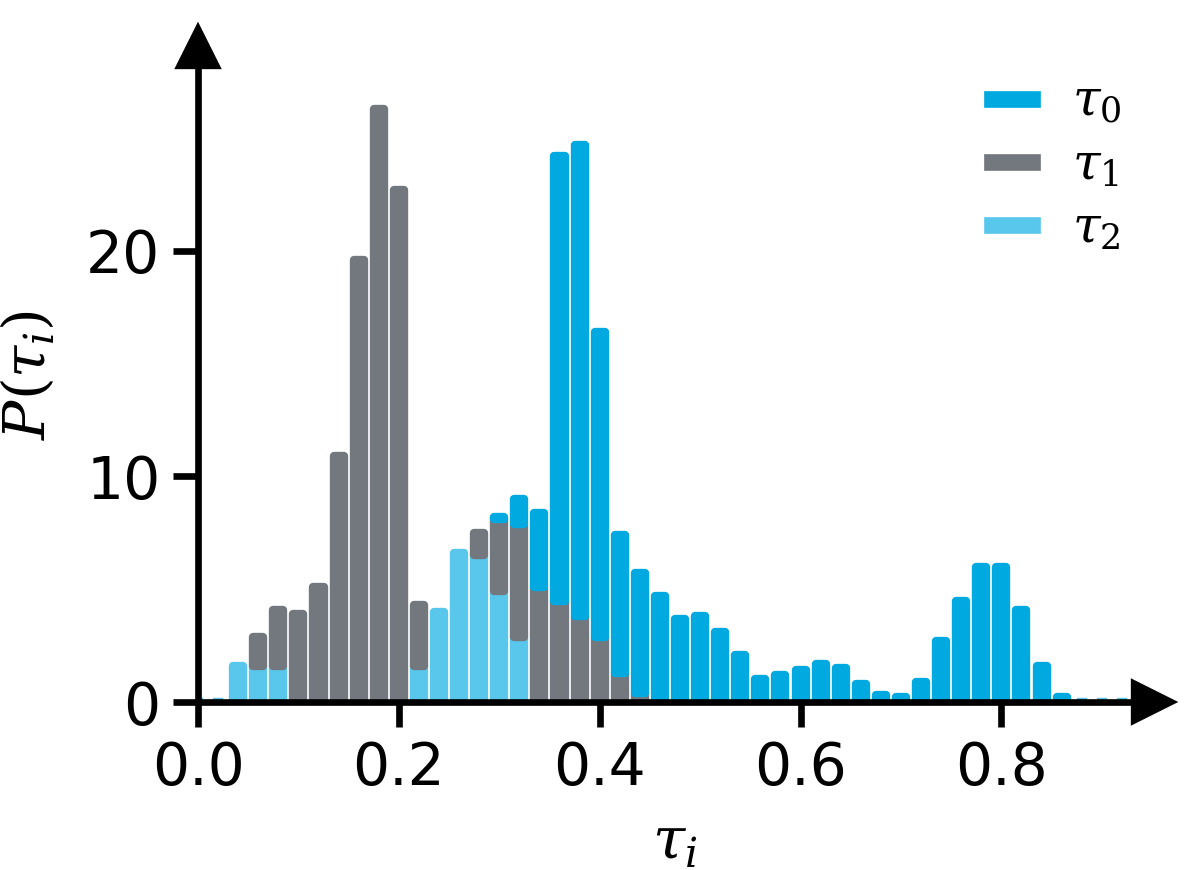

In [63]:
# histogram 2
temp = np.copy(taus[19:262, :3])
temp0 = np.copy(temp[:, 0])
temp1 = np.copy(temp[:, 1])
temp2 = np.copy(temp[:, 2])
temp = np.ravel(temp)
counts, _ = np.histogram(temp[temp > 0.05], bins=100, range=(0, 1))
counts0, _ = np.histogram(temp0[temp0 > 0.05], bins=100, range=(0, 1))
counts1, _ = np.histogram(temp1[temp1 > 0.05], bins=100, range=(0, 1))
counts2, _ = np.histogram(temp2[temp2 > 0.05], bins=100, range=(0, 1))
counts = np.array(counts, dtype=np.float64)
counts0 = np.array(counts0, dtype=np.float64)
counts1 = np.array(counts1, dtype=np.float64)
counts2 = np.array(counts2, dtype=np.float64)

counts_0 = counts[0]
counts_1 = counts[-1]
counts[0] = 0
counts[-1] = 0
counts0_0 = counts0[0]
counts0_1 = counts0[-1]
counts0[0] = 0
counts0[-1] = 0
counts1_0 = counts1[0]
counts1_1 = counts1[-1]
counts1[0] = 0
counts1[-1] = 0
counts2_0 = counts2[0]
counts2_1 = counts2[-1]
counts2[0] = 0
counts2[-1] = 0
counts = savgol_filter(counts, window_length=5, polyorder=0)
counts0 = savgol_filter(counts0, window_length=5, polyorder=0)
counts1 = savgol_filter(counts1, window_length=5, polyorder=0)
counts2 = savgol_filter(counts2, window_length=5, polyorder=0)
counts[0] = counts_0
counts[-1] = counts_1
counts0[0] = counts0_0
counts0[-1] = counts0_1
counts1[0] = counts1_0
counts1[-1] = counts1_1
counts2[0] = counts2_0
counts2[-1] = counts2_1
# # # counts = counts[5:]
# # # counts = savgol_filter(counts, window_length=10, polyorder=0)
# # # plt.plot(bins[5:-1], counts, ".")

valid = counts != 0
valid0 = counts0 != 0
valid1 = counts1 != 0
valid2 = counts2 != 0

tau_bins = np.linspace(0, 1, 100)
new_tau = np.linspace(0, 1.0, 51)
dtau = (new_tau[1] - new_tau[0]) / 4
counted = sc.nanbin_y_over_x(counts[valid], tau_bins[valid], new_tau)
counted0 = sc.nanbin_y_over_x(counts0[valid0], tau_bins[valid0], new_tau)
counted1 = sc.nanbin_y_over_x(counts1[valid1], tau_bins[valid1], new_tau)
counted2 = sc.nanbin_y_over_x(counts2[valid2], tau_bins[valid2], new_tau)
sum_count = np.nansum(counted)

counted0[np.isnan(counted0)] = 0.0
counted1[np.isnan(counted1)] = 0.0
counted2[np.isnan(counted2)] = 0.0

fig, ax = sc.get_figure(
    figsize=(2.0, 1.45),
    padding=(0.25, 0.2),
)
for i, tau_i in enumerate(new_tau):
    ax.fill_between(
        [tau_i - dtau, tau_i + dtau],
        y1=[0, 0],
        y2=[counted2[i], counted2[i]],
        color=sc.seeblau65,
    )
    if counted1[i] > 0:
        ax.fill_between(
            [tau_i - dtau, tau_i + dtau],
            y1=[counted2[i], counted2[i]],
            y2=[counted2[i] + counted1[i], counted2[i] + counted1[i]],
            color=sc.seegrau100,
        )
    if counted[i] - 0.01 > counted2[i] + counted1[i]:
        ax.fill_between(
            [tau_i - dtau, tau_i + dtau],
            y1=[counted2[i] + counted1[i], counted2[i] + counted1[i]],
            y2=[counted[i], counted[i]],
            color=sc.seeblau100,
        )

ax.plot([], [], "-", lw=2, color=sc.seeblau100, label="$\\tau_0$")
ax.plot([], [], "-", lw=2, color=sc.seegrau100, label="$\\tau_1$")
ax.plot([], [], "-", lw=2, color=sc.seeblau65, label="$\\tau_2$")
ax.set_ylim(0, 29)
ax.set_xlim(-0.0, 0.95)


ax.legend(
    handlelength=0.8,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax = sc.theory_layout(
    fig,
    ax,
    title="atomic_contact/breaking/histogram2",
    xlabel="$\\tau_i$",
    ylabel="$P\\left(\\tau_i\\right)$",
)
plt.show()

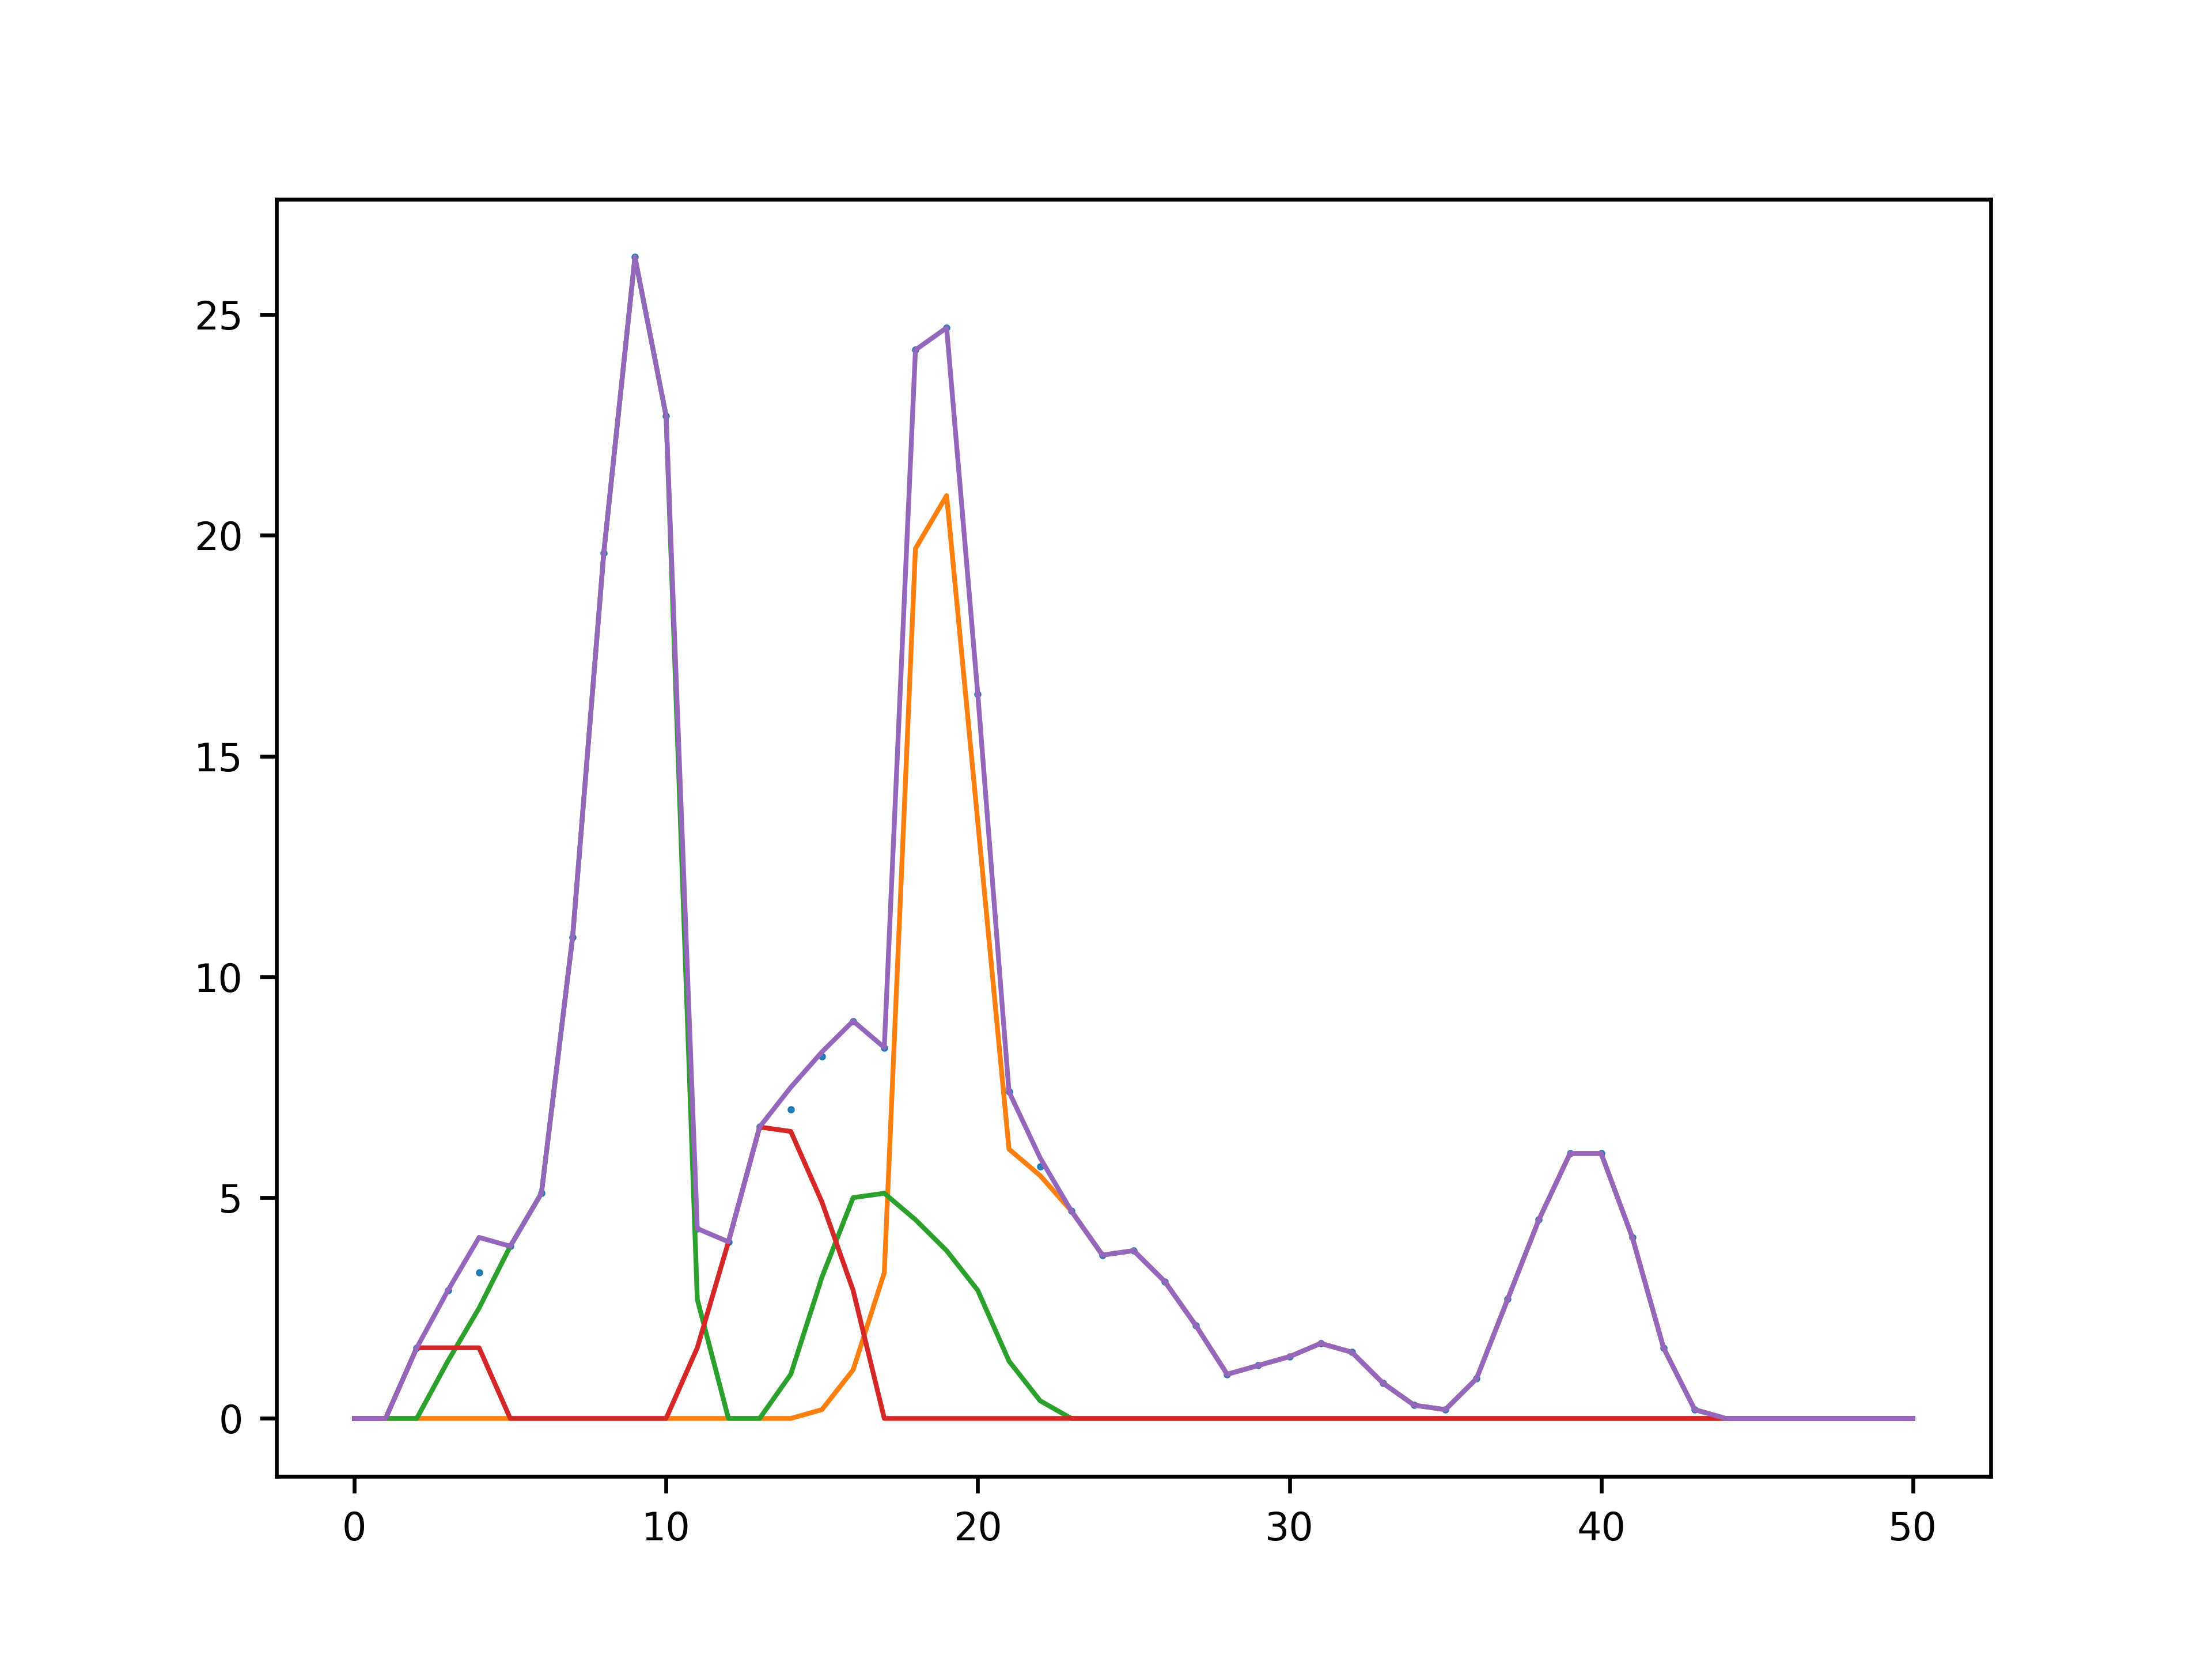

In [33]:
plt.plot(counted, ".")
plt.plot(counted0)
plt.plot(counted1)
plt.plot(counted2)
plt.plot(counted0 + counted1 + counted2)

In [44]:
counts.shape, bins.shape

((100,), (101,))

# Magnetic Field & Temperature Study

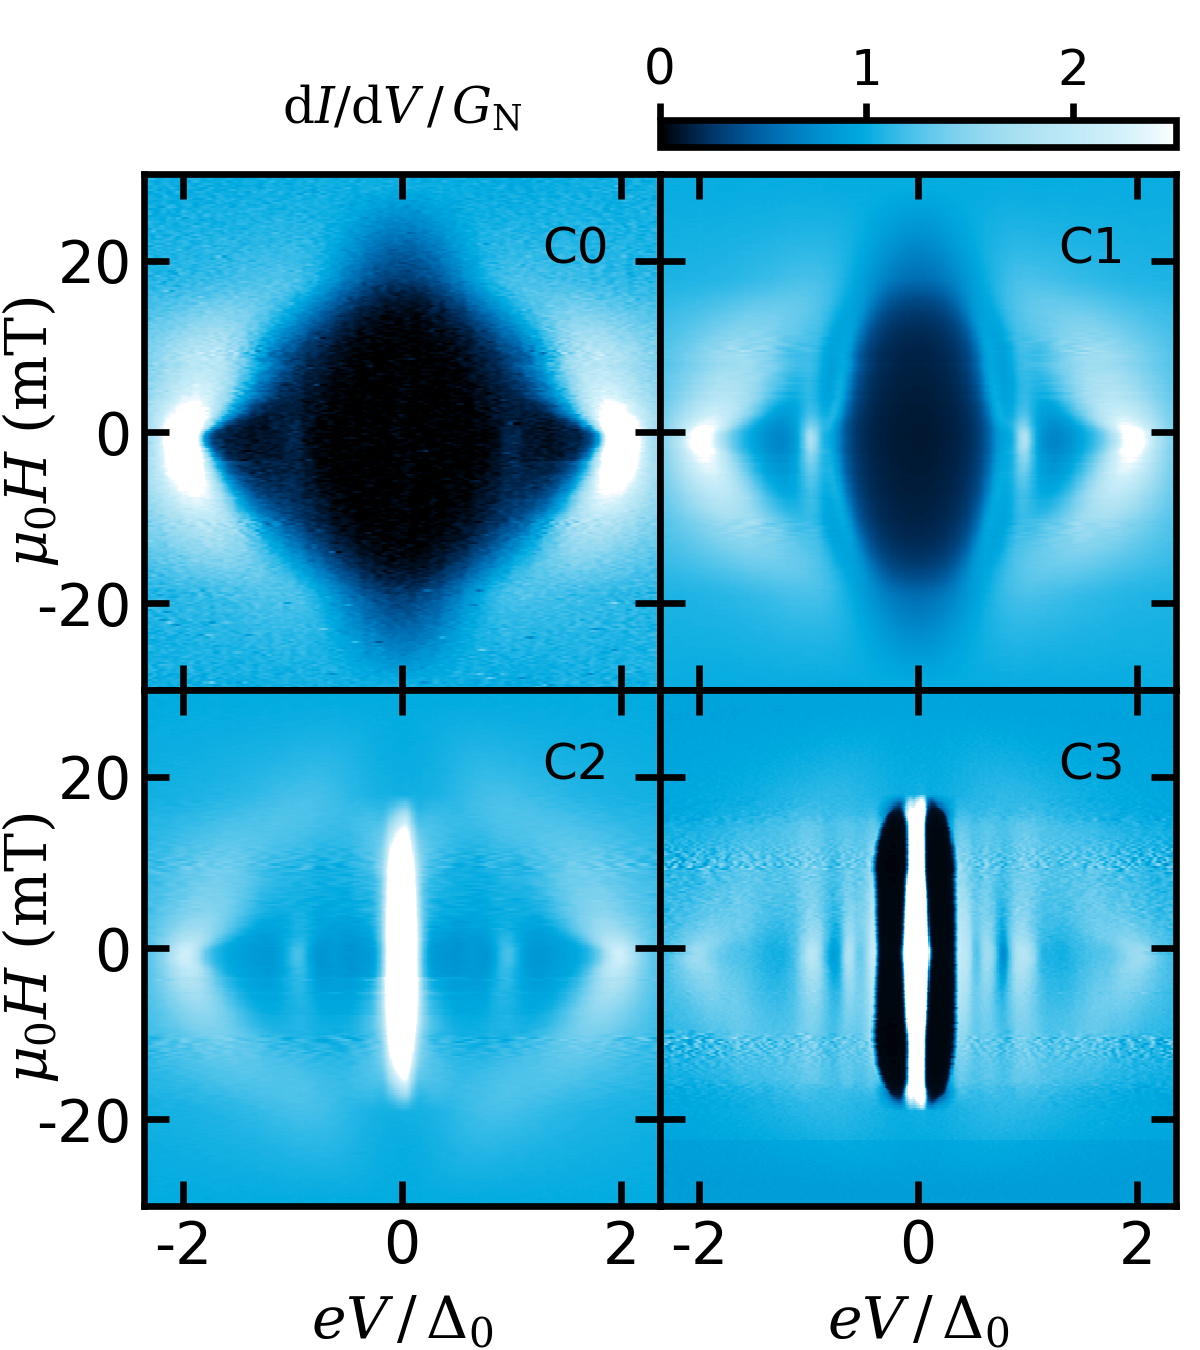

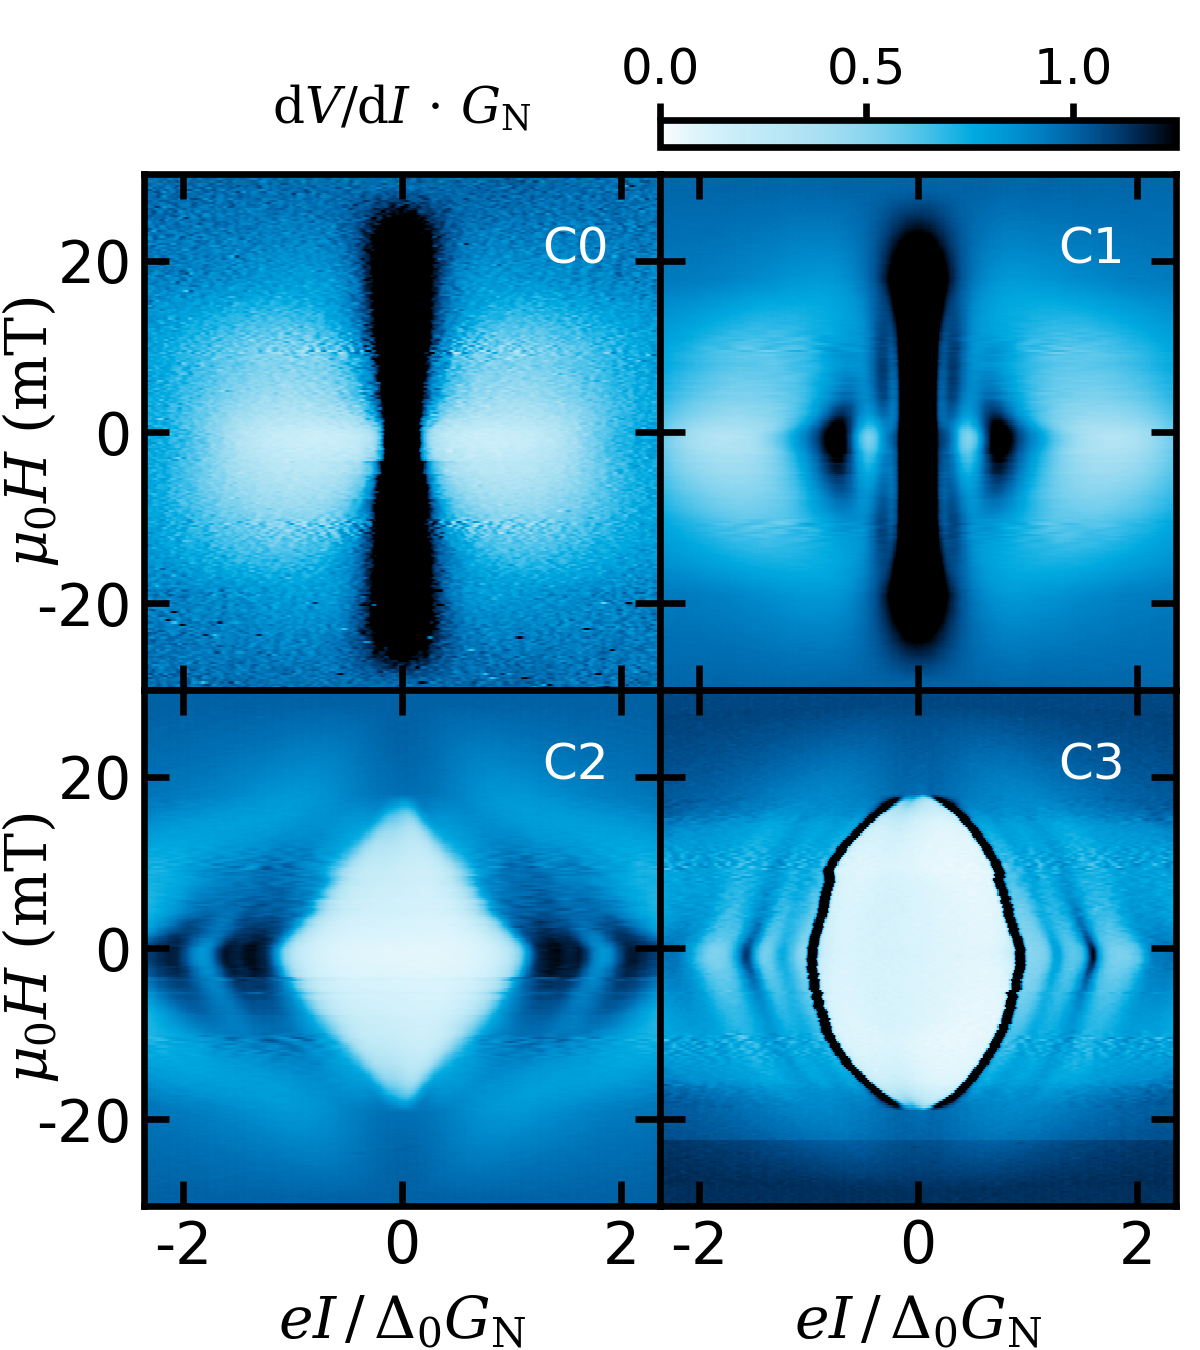

In [2]:
# magnetic field studies
from superconductivity.style.thesislayout import save_figure
from superconductivity.utilities.functions.upsampling import upsample
from superconductivity.utilities.functions.fill_nans import fill

figsize = (2.0, 2.25)
padding = (0.2, 0.2, 0.0, 0.25)

dGlim = (-1.3, 1.3)
dRlim = (-1.3, 1.3)

base = ["0.05", "1.8", "2.4", "43.0"]

# region dIdV
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=2, ncols=2)
for i, ax in enumerate(axes):
    data = np.load(f"magnetic-field/{base[i]}G0/cal.npz")
    img = ax.pcolormesh(
        data["Vbias"],
        data["uH"] * data["uHc_mT"],
        data["dGexp"],
        cmap=sc.get_cmap(),
        clim=(0, 2.5),
        rasterized=True,
    )
    ax.text(
        0.9,
        0.9,
        # (
        #     f"${data["GN_G0"]:.3f}\\,G_0$"
        #     if data["GN_G0"] < 10
        #     else f"${data["GN_G0"]:.2f}\\,G_0$"
        # ),
        f"C{i}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        size=6,
    )

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$\\mu_0H\\ (\\mathrm{mT})$",
    xticks=[-2, 0, 2],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = min(ax.get_position().x0 for ax in axes)
right = max(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.5
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax = fig.add_axes([new_left, upper_edge + 0.02, new_width, 0.02])
cax.text(
    -0.5,
    0.5,
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    transform=cax.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
)
cbar.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
save_figure(fig, title=f"atomic_contact/magnetic-field/dGexp")
# endregion


# region dIdV
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=2, ncols=2)
for i, ax in enumerate(axes):
    data = np.load(f"magnetic-field/{base[i]}G0/cal.npz")
    img = ax.pcolormesh(
        data["Ibias"],
        data["uH"] * data["uHc_mT"],
        data["dRexp"],
        cmap=sc.get_cmap(inverse=True),
        clim=(0, 1.25),
        rasterized=True,
    )
    ax.text(
        0.9,
        0.9,
        # (
        #     f"${data["GN_G0"]:.3f}\\,G_0$"
        #     if data["GN_G0"] < 10
        #     else f"${data["GN_G0"]:.2f}\\,G_0$"
        # ),
        f"C{i}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        size=6,
        color=[1, 1, 1, 1],
    )

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eI\\,/\\,\\Delta_0 G_\\mathrm{N}$",
    ylabel="$\\mu_0H\\ (\\mathrm{mT})$",
    xticks=[-2, 0, 2],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = min(ax.get_position().x0 for ax in axes)
right = max(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.5
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax = fig.add_axes([new_left, upper_edge + 0.02, new_width, 0.02])
cax.text(
    -0.5,
    0.5,
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_\\mathrm{N}$",
    transform=cax.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
)
cbar.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
save_figure(fig, title=f"atomic_contact/magnetic-field/dRexp")
# endregion


plt.show()

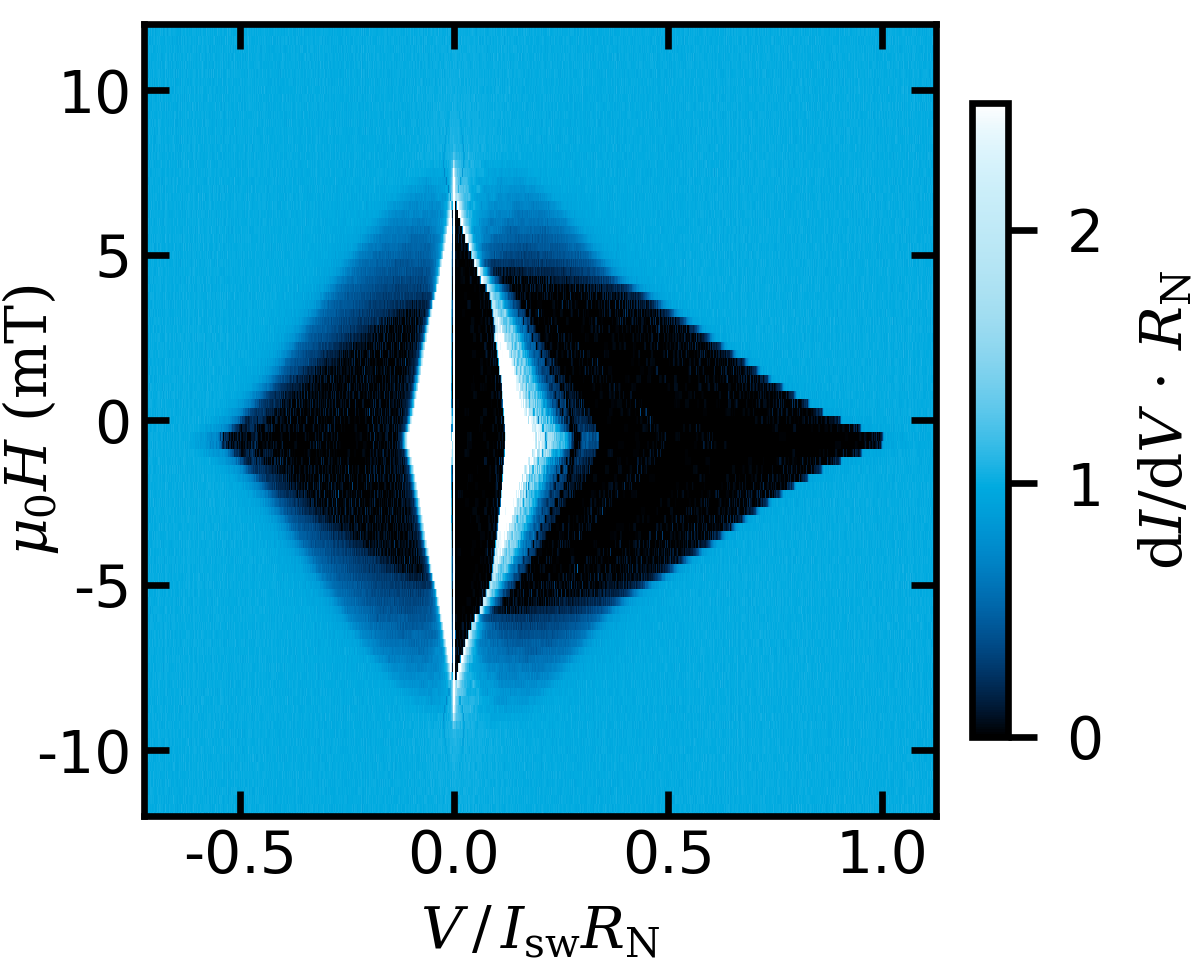

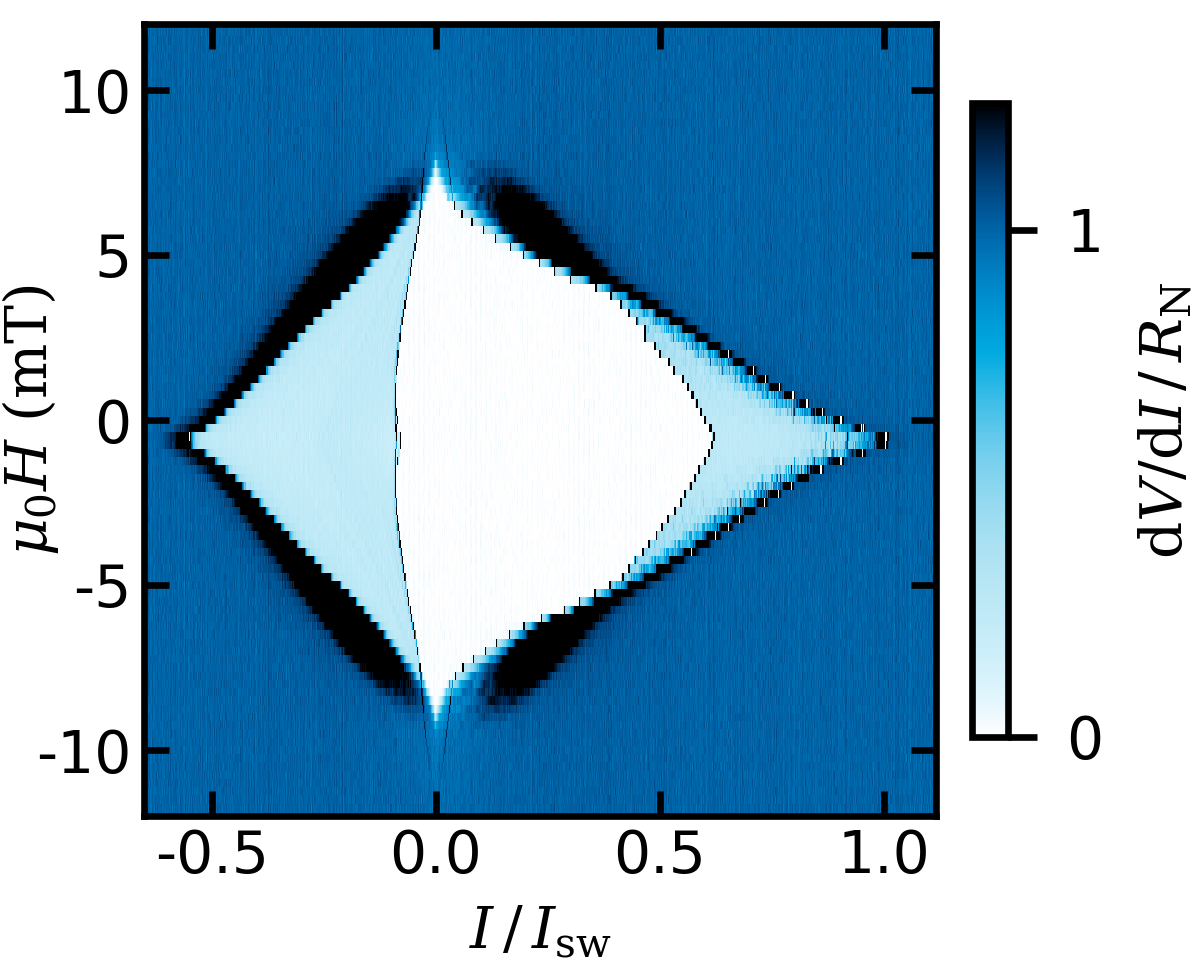

In [84]:
# magnetic field unbroken

from superconductivity.style.thesislayout import save_figure

path = "magnetic-field/550.0G0"
data = np.load(f"{path}/cal.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
uH_mT = data["uH"] * data["uHc_mT"]

dGexp = data["dGexp"]
dRexp = data["dRexp"]

figsize = (2.0, 1.6)
padding = (0.2, 0.2, 0.4, 0.0)

# region dIdV
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    uH_mT,
    dGexp,
    cmap=sc.get_cmap(bad="k", inverse=False),
    clim=(-0, 2.5),
    rasterized=True,
)
axes[0].set_ylim(-12, 12)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$V\\,/\\,I_\\mathrm{sw}R_\\mathrm{N}$",
    ylabel="$\\mu_0H\\ (\\mathrm{mT})$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.03, new_bottom, 0.03, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=[0, 1, 2, 3])
cbar.set_label("$\\mathrm{d}I/\\mathrm{d}V\\,\\cdot\\,R_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"atomic_contact/{path}/dGexp")
# endregion

# region dIdV
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Ibias,
    uH_mT,
    dRexp,
    cmap=sc.get_cmap(bad="grey", inverse=True),
    clim=(-0, 1.25),
    rasterized=True,
)
axes[0].set_ylim(-12, 12)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$I\\,/\\,I_\\mathrm{sw}$",
    ylabel="$\\mu_0H\\ (\\mathrm{mT})$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.03, new_bottom, 0.03, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=[0, 1, 2, 3])
cbar.set_label("$\\mathrm{d}V/\\mathrm{d}I\\,/\\,R_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"atomic_contact/{path}/dRexp")
# endregion

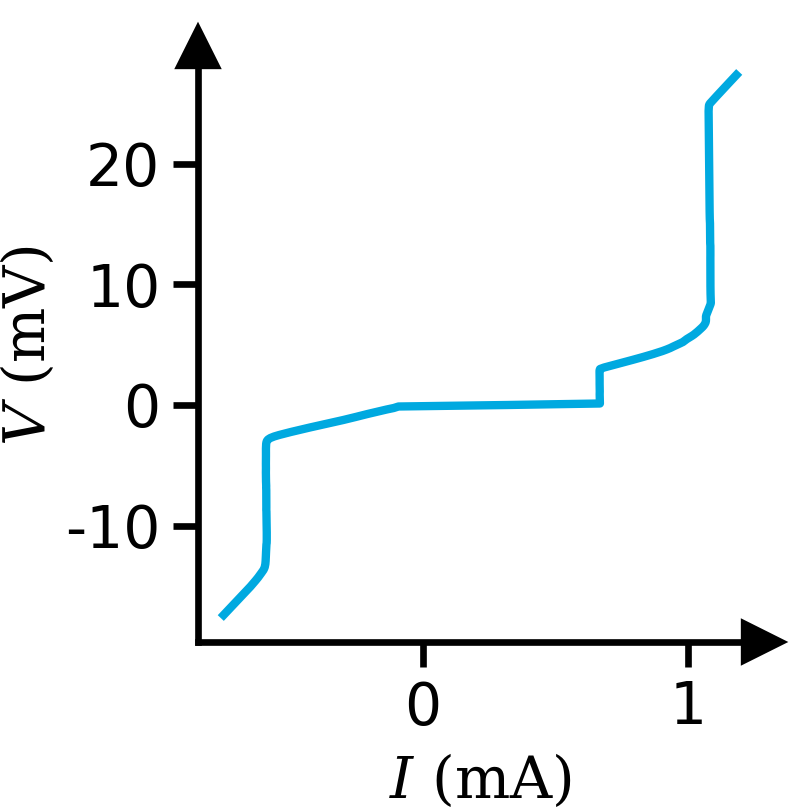

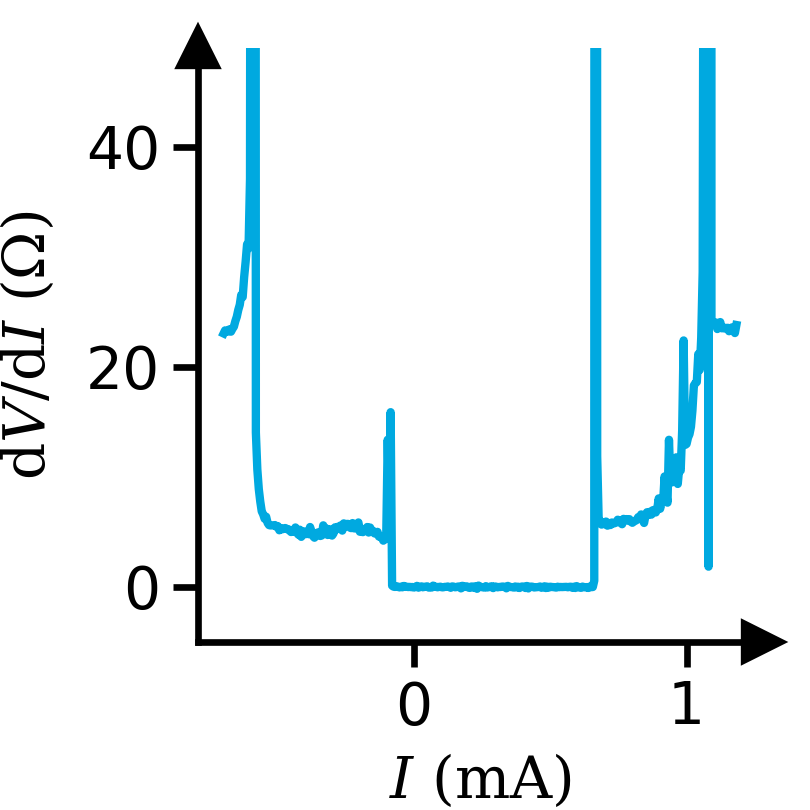

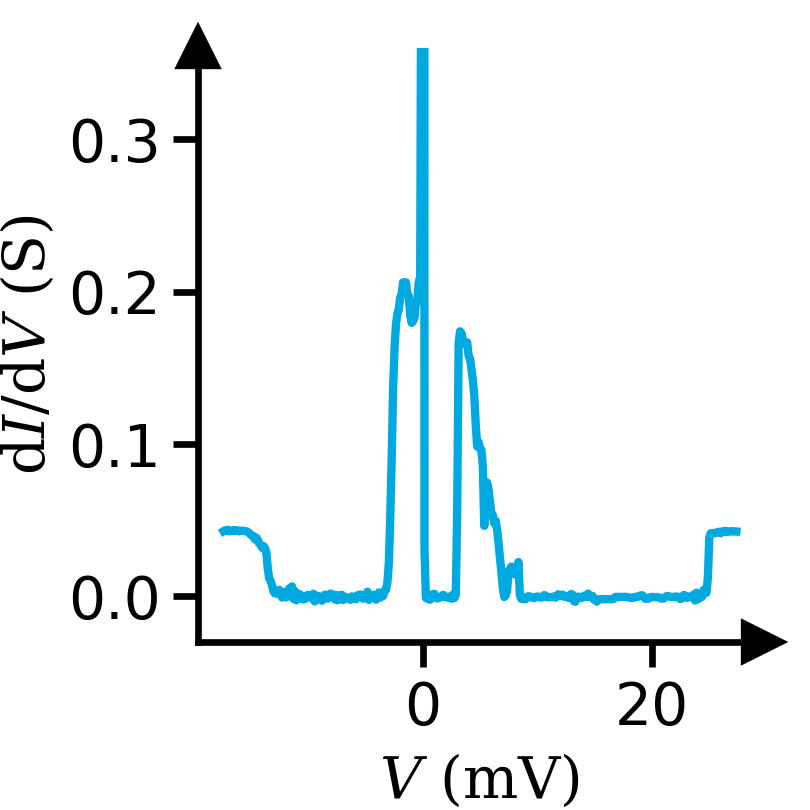

In [42]:
# magnetic field unbroken single vi
from superconductivity.utilities.functions.upsampling import upsample

path = "magnetic-field/550.0G0"
data = np.load(f"{path}/cal0.npz")

RN_Ohm = data["RN_Ohm"]
Ic_nA = data["Ic_nA"]

Vbias_mV = data["Vbias"] / (1e6 / RN_Ohm / Ic_nA)
Ibias_mA = data["Ibias"] * Ic_nA / 1e6
uH_mT = data["uH"] * data["uHc_mT"]

index = 58
Iexp_mA = data["Iexp"][index, :] * Ic_nA / 1e6
Vexp_mV = data["Vexp"][index, :] / (1e6 / RN_Ohm / Ic_nA)
dGexp_S = data["dGexp"][index, :] / RN_Ohm
dRexp_Ohm = data["dRexp"][index, :] * RN_Ohm

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Iexp_mA,
    Vbias_mV,
    "-",
    color=sc.seeblau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.5)

sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/magnetic-field/550.0G0/vi",
    "$I\\ \\mathrm{(mA)}$",
    "$V\\ \\mathrm{(mV)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Ibias_mA, dRexp_Ohm, "-", color=sc.seeblau100)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.5)
ax.set_ylim(-5, 49)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/magnetic-field/550.0G0/dvdi",
    "$I\\ \\mathrm{(mA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\ (\\Omega)$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, dGexp_S, "-", color=sc.seeblau100)
ax.set_ylim(-0.03, 0.36)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/magnetic-field/550.0G0/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\ (\\mathrm{S})$",
)
# plt.show()

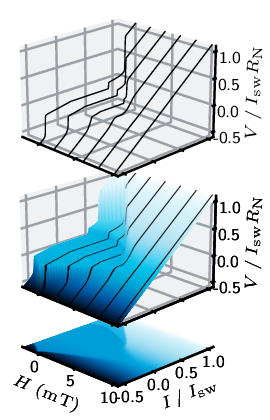

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/550.0G0/cal_iv/main.png

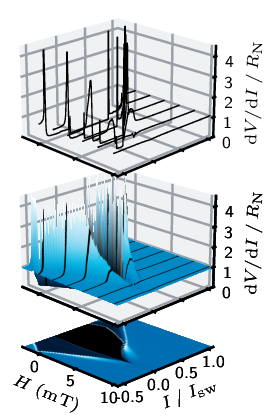

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/550.0G0/cal_didv/main.png

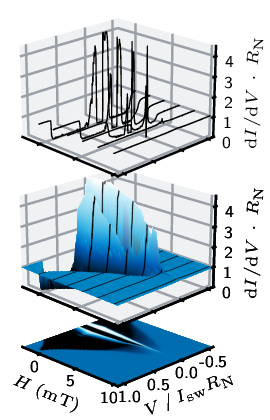

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/550.0G0/cal_dvdi/main.png

In [3]:
# magnetic field unbroken landscape
import numpy as np
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample

data = np.load(
    f"magnetic-field/550.0G0/cal0.npz",
)
Vbias = data["Vbias"]
Ibias = data["Ibias"]
uH_mT = data["uH"] * data["uHc_mT"]
Vexp = data["Vexp"]
dGexp = data["dGexp"]
dRexp = data["dRexp"]

from superconductivity.visuals.landscape import export_landscape_thesis

exports = export_landscape_thesis(
    Vbias=Ibias,
    Abias=uH_mT,
    Ibias=Vbias,
    Iexp=Vexp,
    dGexp=dRexp,
    dRexp=dGexp,
    surface_points=(300, 100),
    surface_center_width_y=0,
    Vbiaslim=(-0.6, 1.1),
    Abiaslim=(-2.5, 10.5),
    Ibiaslim=(-0.6, 1.1),
    Ilim=(-0.6, 1.1),
    dGlim=(-0, 4.5),
    dRlim=(-0, 4.5),
    Ilabel="$V\\,/\\,I_\\mathrm{sw}R_\\mathrm{N}$",
    Vlabel="$I\\,/\\,I_\\mathrm{sw}$",
    Alabel="$H\\ (\\mathrm{mT})$",
    dGlabel=r"$\mathrm{d}V/\mathrm{d}I\,/\,R_\mathrm{N}$",
    dRlabel=r"$\mathrm{d}I/\mathrm{d}V\,\cdot\,R_\mathrm{N}$",
    Vbiasticks=[-0.5, 0, 0.5, 1.0],
    Abiasticks=[0, 5, 10],
    Ibiasticks=[-0.5, 0, 0.5, 1.0],
    Iticks=[-0.5, 0, 0.5, 1.0],
    waterfall_traces=[0, 2, 4, 6, 8, 10],
    name="cal",
    sub_dir=f"atomic_contact/magnetic-field/550.0G0",
)

# exports = export_amplitude_maps_thesis(
#     Vbias=Ibias,
#     Abias=uH_mT[50:],
#     Ibias=Vbias,
#     Iexp=Vexp[50:, :],
#     dGexp=dRexp[50:, :],
#     dRexp=dGexp[50:, :],
#     Vbiaslim=(-0.6, 1.1),
#     Abiaslim=(-2.5, 10.5),
#     Ibiaslim=(-0.6, 1.1),
#     Ilim=(-0.6, 1.1),
#     Ilabel="$V\\,/\\,I_\\mathrm{sw}R_\\mathrm{N}$",
#     Vlabel="$I\\,/\\,I_\\mathrm{sw}$",
#     Alabel="$H\\ (\\mathrm{mT})$",
#     dGlabel=r"$\mathrm{d}V/\mathrm{d}I\,/\,R_\mathrm{N}$",
#     dRlabel=r"$\mathrm{d}I/\mathrm{d}V\,\cdot\,R_\mathrm{N}$",
#     Vbiasticks=[-0.5, 0, 0.5, 1.0],
#     Abiasticks=[0, 5, 10],
#     Ibiasticks=[-0.5, 0, 0.5, 1.0],
#     Iticks=[-0.5, 0, 0.5, 1.0],
#     waterfall_traces=[0, 2, 4, 6, 8, 10],
#     name="cal",
#     sub_dir=f"atomic_contact/magnetic-field/550.0G0",
# )

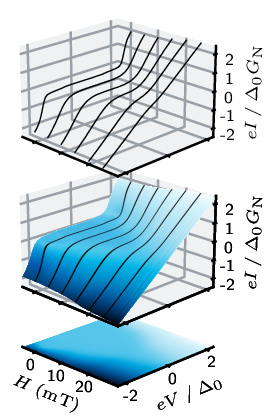

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/0.05G0/cal_iv/main.png

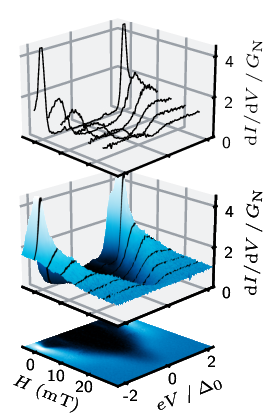

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/0.05G0/cal_didv/main.png

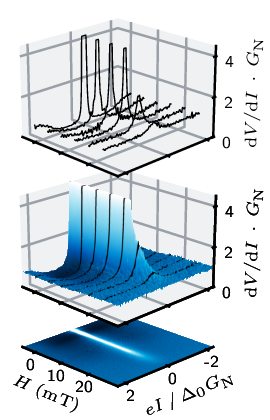

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/0.05G0/cal_dvdi/main.png

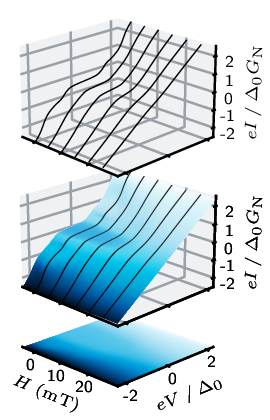

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/1.8G0/cal_iv/main.png

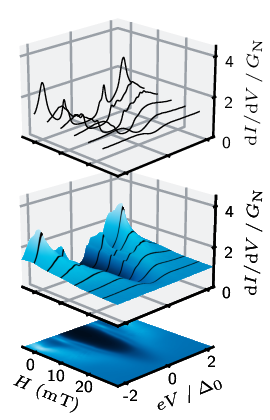

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/1.8G0/cal_didv/main.png

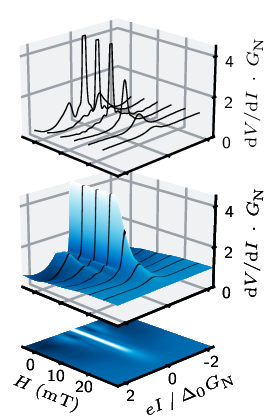

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/1.8G0/cal_dvdi/main.png

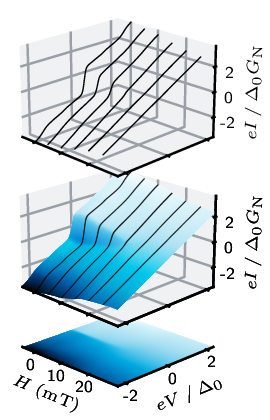

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/2.4G0/cal_iv/main.png

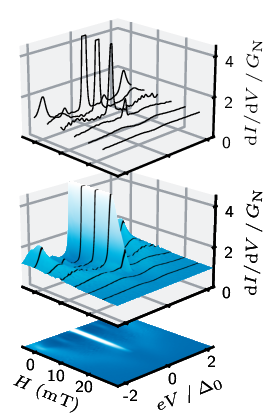

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/2.4G0/cal_didv/main.png

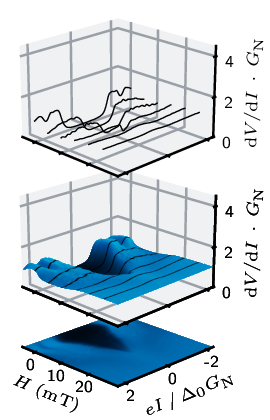

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/2.4G0/cal_dvdi/main.png

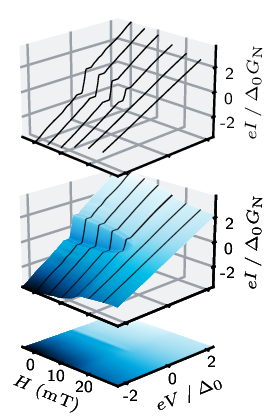

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/43.0G0/cal_iv/main.png

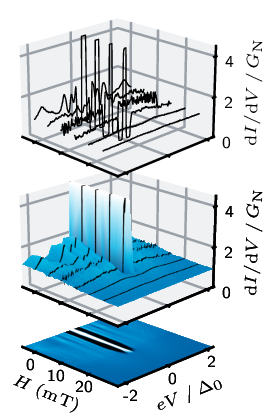

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/43.0G0/cal_didv/main.png

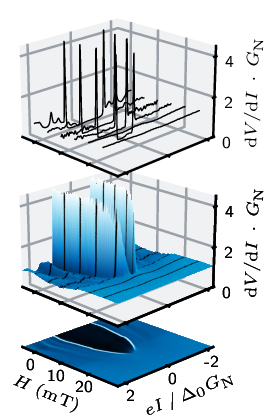

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/magnetic-field/43.0G0/cal_dvdi/main.png

In [2]:
# 0.05 G0, magnetic field
import numpy as np
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample

from superconductivity.visuals.landscape import export_landscape_thesis

base = ["0.05", "1.8", "2.4", "43.0"]

# region dIdV
for i, b in enumerate(base):
    data = np.load(f"magnetic-field/{b}G0/cal.npz")
    Vbias = data["Vbias"]
    uH0_mT = data["uH"] * data["uHc_mT"]
    Iexp = data["Iexp"]
    dGexp = data["dGexp"]
    dRexp = data["dRexp"]

    exports = export_landscape_thesis(
        Vbias=Vbias,
        Abias=uH0_mT,
        Ibias=Vbias,
        Iexp=Iexp,
        dGexp=dGexp,
        dRexp=dRexp,
        surface_points=(300, 100),
        surface_center_width_y=0,
        Abiaslim=(-5, 30),
        dGlim=(0, 4.5),
        dRlim=(0, 4.5),
        Abiasticks=[0, 10, 20],
        dGticks=[0, 2, 4],
        dRticks=[0, 2, 4],
        Alabel="$H\\ (\\mathrm{mT})$",
        waterfall_traces=[0, 5, 10, 15, 20, 25],
        name="cal",
        sub_dir=f"atomic_contact/magnetic-field/{b}G0",
    )
# print(Iexp.shape, dGexp.shape, Vbias.shape, dRexp.shape)

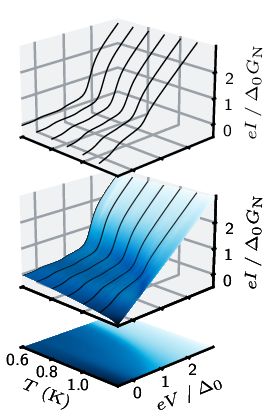

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/temperature/cal_iv/main.png

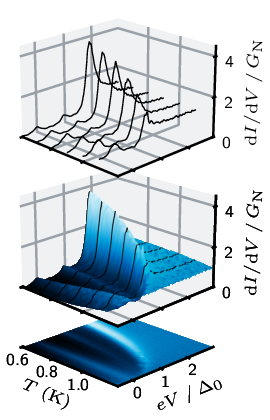

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/temperature/cal_didv/main.png

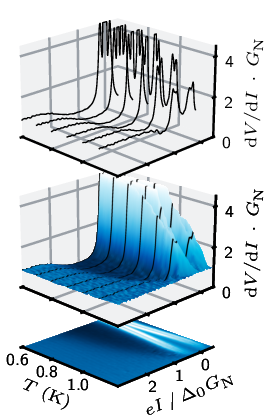

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/temperature/cal_dvdi/main.png

In [8]:
# 0.05 G0, temperature study
import numpy as np
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample

data = np.load(
    f"temperature/cal.npz",
)
Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
Tbath0 = data["Tbath"]
Iexp0 = data["Iexp"]
dGexp0 = data["dGexp"]
dRexp0 = data["dRexp"]

# Tbath = np.linspace(0.5, 1.0, 51)
# Vbias = np.linspace(-0.5, 3.0, 251)
# Ibias = np.linspace(-0.5, 2.99, 251)

# Iexp1 = np.full((Tbath0.shape[0], Vbias.shape[0]), np.nan)
# Vexp1 = np.full((Tbath0.shape[0], Ibias.shape[0]), np.nan)

# for i, _ in enumerate(Tbath0):
#     mask = np.isfinite(Iexp0[i, :])
#     if np.sum(mask) > 2:
#         Iexp1[i, :] = sc.nanbin_y_over_x(
#             upsample(Iexp0[i, mask], axis=-1),
#             upsample(Vbias0[mask], axis=-1),
#             Vbias,
#         )
#         Vexp1[i, :] = sc.nanbin_y_over_x(
#             upsample(Vbias0[mask], axis=-1),
#             upsample(Iexp0[i, mask], axis=-1),
#             Ibias,
#         )

# Iexp = sc.nanbin_y_over_x(
#     upsample(Iexp1[30:, :], axis=0), upsample(Tbath0[30:]), Tbath, axis=0
# )
# Vexp = sc.nanbin_y_over_x(
#     upsample(Vexp1[30:, :], axis=0), upsample(Tbath0[30:]), Tbath, axis=0
# )

# dGexp = np.gradient(Iexp, Vbias, axis=-1)
# dRexp = np.gradient(Vexp, Ibias, axis=-1)

# exports = export_amplitude_maps_thesis(
#     Vbias=Vbias,
#     Abias=Tbath * 1.21,
#     Ibias=Ibias,
#     Iexp=Iexp,
#     dGexp=dGexp,
#     dRexp=dRexp,
#     Vbiaslim=(-0.5, 3.0),
#     Ibiaslim=(-0.5, 3.0),
#     Abiaslim=(0.6, 1.21),
#     Ilim=(-0.5, 3.0),
#     dGlim=(0, 4.5),
#     dRlim=(0, 4.5),
#     Vbiasticks=[0, 1, 2],
#     Ibiasticks=[0, 1, 2],
#     Abiasticks=[0.6, 0.8, 1.0],
#     Iticks=[0, 1, 2],
#     dGticks=[0, 2, 4],
#     dRticks=[0, 2, 4],
#     Alabel="$T\\ (\\mathrm{K})$",
#     waterfall_traces=[0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
#     name="cal",
#     sub_dir=f"atomic_contact/temperature",
# )

exports = export_landscape_thesis(
    Vbias=Vbias0,
    Abias=Tbath0 * 1.21,
    Ibias=Ibias0,
    Iexp=Iexp0,
    dGexp=dGexp0,
    dRexp=dRexp0,
    surface_points=(300, 100),
    surface_center_width_y=0,
    Vbiaslim=(-0.5, 3.0),
    Ibiaslim=(-0.5, 3.0),
    Abiaslim=(0.6, 1.21),
    Ilim=(-0.5, 3.0),
    dGlim=(0, 4.5),
    dRlim=(0, 4.5),
    Vbiasticks=[0, 1, 2],
    Ibiasticks=[0, 1, 2],
    Abiasticks=[0.6, 0.8, 1.0],
    Iticks=[0, 1, 2],
    dGticks=[0, 2, 4],
    dRticks=[0, 2, 4],
    Alabel="$T\\ (\\mathrm{K})$",
    waterfall_traces=[0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    name="cal",
    sub_dir=f"atomic_contact/temperature",
)

In [ ]:
# # 0.05, powers at 15 GHz, exp
# data = np.load("0.05G0/15.0GHz_stripline/cal.npz")

# Vbias0_mV = data["Vbias_mV"]
# Ibias0_nA = data["Ibias_nA"]
# # Pout_dBm = data["Pout_dBm"]
# Aout_mV = data["Aout_mV"]
# nu_GHz = data["nu_GHz"]
# dGexp0_G0 = data["dGexp_G0"]
# dRexp0_R0 = data["dRexp_R0"]
# Iexp0_nA = data["Iexp_nA"]
# Tbath_K = data["Tbath_K"]

# datafit = np.load("0.05G0/15.0GHz_stripline/fit_pat.npz")
# eta = datafit["eta"]
# GN_G0 = np.nanmedian(datafit["GN_G0"])
# Delta_meV = np.nanmedian(datafit["Delta_meV"])

# Vbias_mV = np.linspace(-0.5, 4.5, 501) * Delta_meV
# Ibias_nA = np.linspace(-0.5, 4.5, 501) * (GN_G0 * sc.G0_muS * Delta_meV)

# Iexp_nA = sc.bin_y_over_x(Iexp0_nA, Vbias0_mV, Vbias_mV, axis=1)
# dGexp_G0 = sc.bin_y_over_x(dGexp0_G0, Vbias0_mV, Vbias_mV, axis=1)
# dRexp_R0 = sc.bin_y_over_x(dRexp0_R0, Ibias0_nA, Ibias_nA, axis=1)

# from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
# exports = export_amplitude_maps_thesis(
#     Vbias=Vbias_mV,
#     Abias=Aout_mV[::3],
#     Ibias=Ibias_nA,
#     Iexp=Iexp_nA[::3, :],
#     dGexp=dGexp_G0[::3, :],
#     dRexp=dRexp_R0[::3, :],
#     waterfall_traces=5,
#     Vbiaslim=(-0.5 * Delta_meV, 4.5 * Delta_meV),
#     Abiaslim=(0, 1.0 / eta),
#     Ibiaslim=(
#         -0.5 * (GN_G0 * sc.G0_muS * Delta_meV),
#         4.5 * (GN_G0 * sc.G0_muS * Delta_meV),
#     ),
#     Ilim=(
#         -0.5 * (GN_G0 * sc.G0_muS * Delta_meV),
#         4.5 * (GN_G0 * sc.G0_muS * Delta_meV),
#     ),
#     dGlim=(-0.05 * GN_G0, 4.5 * GN_G0),
#     dRlim=(-0.05 / GN_G0, 4.5 / GN_G0),
#     Vbiasticks=None,
#     Abiasticks=None,
#     Ibiasticks=None,
#     Iticks=None,
#     dGticks=None,
#     dRticks=None,
#     Vlabel="$V\\,\\mathrm{(mV)}$",
#     Alabel="$A_\\mathrm{out}\\,\\mathrm{(mV)}$",
#     Ilabel="$I\\,\\mathrm{(nA)}$",
#     dGlabel=r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{0}$",
#     dRlabel=r"$\mathrm{d}V/\mathrm{d}I\,\cdot\,G_\mathrm{0}$",
#     name="exp",
#     sub_dir=f"atomic_contact/0.05G0/15.0GHz_stripline/",
# )

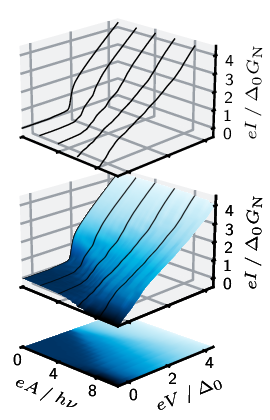

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/0.05G0/15.0GHz_stripline/cal_iv/main.png

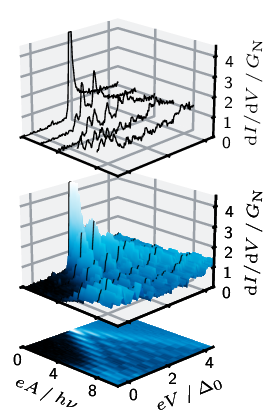

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/0.05G0/15.0GHz_stripline/cal_didv/main.png

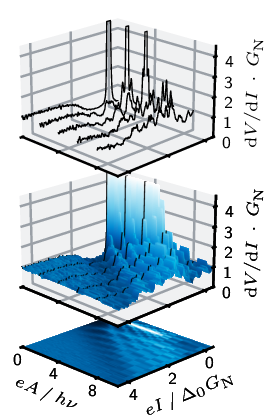

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/0.05G0/15.0GHz_stripline/cal_dvdi/main.png

In [9]:
# 0.05, powers at 15 GHz, cal
datafit = np.load("0.05G0/15.0GHz_stripline/fit_pat.npz")
eta = datafit["eta"]
GN_G0 = np.nanmedian(datafit["GN_G0"])
Delta_meV = np.nanmedian(datafit["Delta_meV"])

data = np.load("0.05G0/15.0GHz_stripline/cal.npz")
Aout_mV = data["Aout_mV"]
nu_GHz = data["nu_GHz"]
Tbath_K = data["Tbath_K"]

Vbias0_mV = data["Vbias_mV"]
Ibias0_nA = data["Ibias_nA"]
Iexp0_nA = data["Iexp_nA"]
dGexp0_G0 = data["dGexp_G0"]
dRexp0_R0 = data["dRexp_R0"]

Vbias0 = Vbias0_mV / Delta_meV
Ibias0 = Ibias0_nA / (GN_G0 * sc.G0_muS * Delta_meV)
Iexp0 = Iexp0_nA / (GN_G0 * sc.G0_muS * Delta_meV)
dGexp0 = dGexp0_G0 / GN_G0
dRexp0 = dRexp0_R0 * GN_G0
Abias0 = eta * Aout_mV / (sc.h_pVs * nu_GHz)


# Vbias = np.linspace(-0.5, 4.5, 251)
# Ibias = np.linspace(-0.5, 4.5, 251)
# Abias = eta * Aout_mV / (sc.h_pVs * nu_GHz)

# Iexp = sc.bin_y_over_x(Iexp0, Vbias0, Vbias, axis=1)
# dGexp = sc.bin_y_over_x(dGexp0, Vbias0, Vbias, axis=1)
# dRexp = sc.bin_y_over_x(dRexp0, Ibias0, Ibias, axis=1)

# from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

# exports = export_amplitude_maps_thesis(
#     Vbias=Vbias,
#     Abias=Abias,
#     Ibias=Ibias,
#     Iexp=Iexp,
#     dGexp=dGexp,
#     dRexp=dRexp,
#     waterfall_traces=[0, 2, 4, 6, 8],
#     Abiaslim=(0, 10),
#     Ilim=(-0.5, 4.5),
#     Abiasticks=[0, 4, 8],
#     name="cal",
#     sub_dir=f"atomic_contact/0.05G0/15.0GHz_stripline/",
# )


exports = export_landscape_thesis(
    Vbias=Vbias0,
    Abias=Abias0,
    Ibias=Ibias0,
    Iexp=Iexp0,
    dGexp=dGexp0,
    dRexp=dRexp0,
    surface_points=(300, None),
    surface_center_width_y=0.66,
    waterfall_traces=[0, 2, 4, 6, 8],
    Vbiaslim=(-0.5, 4.5),
    Ibiaslim=(-0.5, 4.5),
    Abiaslim=(0, 10),
    Ilim=(-0.5, 4.5),
    dRlim=(0, 4.5),
    dGlim=(0, 4.5),
    Abiasticks=[0, 4, 8],
    name="cal",
    sub_dir=f"atomic_contact/0.05G0/15.0GHz_stripline/",
)

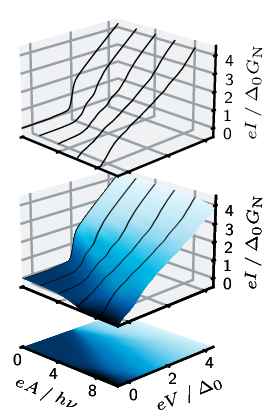

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/0.05G0/15.0GHz_stripline/sim_iv/main.png

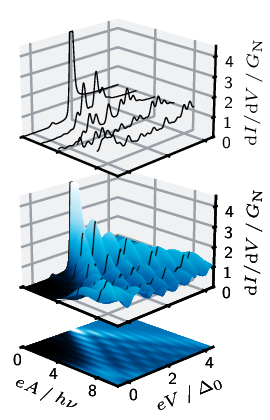

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/0.05G0/15.0GHz_stripline/sim_didv/main.png

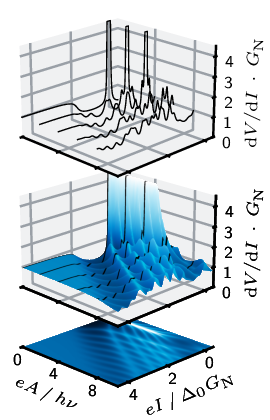

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/0.05G0/15.0GHz_stripline/sim_dvdi/main.png

In [10]:
# 0.05, powers at 15 GHz, sim
import numpy as np

data = np.load("0.05G0/15.0GHz_stripline/sim.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Abias = data["Abias"]
Isim = data["Isim"]
dGsim = data["dGsim"]
dRsim = data["dRsim"]

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

# exports = export_amplitude_maps_thesis(
#     Vbias=Vbias,
#     Abias=Abias,
#     Ibias=Ibias,
#     Iexp=Isim,
#     dGexp=dGsim,
#     dRexp=dRsim,
#     waterfall_traces=[0, 2, 4, 6, 8],
#     Abiaslim=(0, 10),
#     Ilim=(-0.5, 4.5),
#     Abiasticks=[0, 4, 8],
#     name="sim",
#     sub_dir=f"atomic_contact/0.05G0/15.0GHz_stripline/",
# )

exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Isim,
    dGexp=dGsim,
    dRexp=dRsim,
    surface_points=(300, 100),
    surface_center_width_y=0.0,
    waterfall_traces=[0, 2, 4, 6, 8],
    Vbiaslim=(-0.5, 4.5),
    Ibiaslim=(-0.5, 4.5),
    Abiaslim=(0, 10),
    Ilim=(-0.5, 4.5),
    dRlim=(0, 4.5),
    dGlim=(0, 4.5),
    Abiasticks=[0, 4, 8],
    name="sim",
    sub_dir=f"atomic_contact/0.05G0/15.0GHz_stripline/",
)

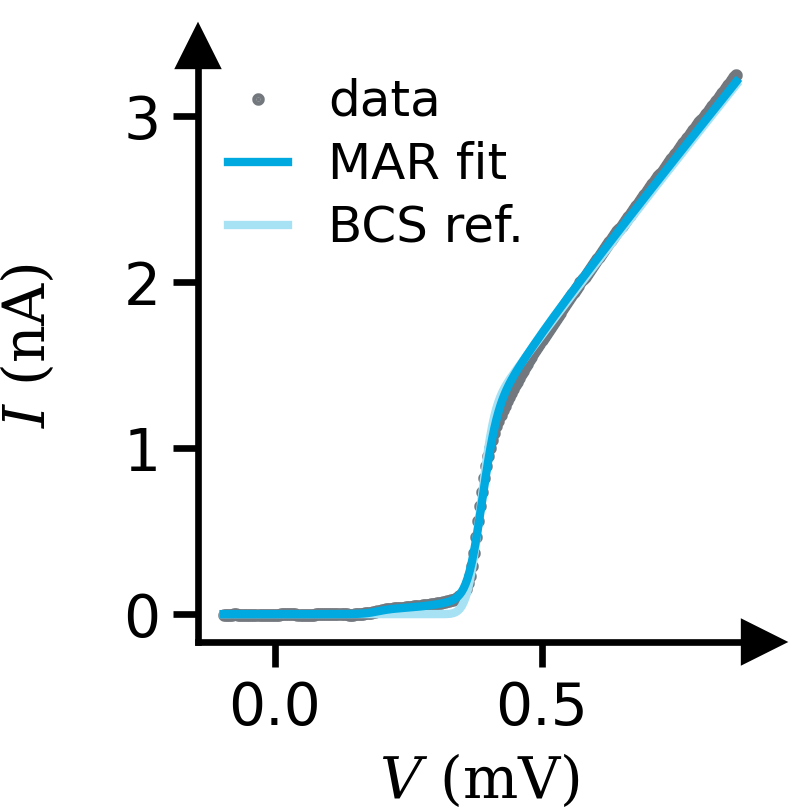

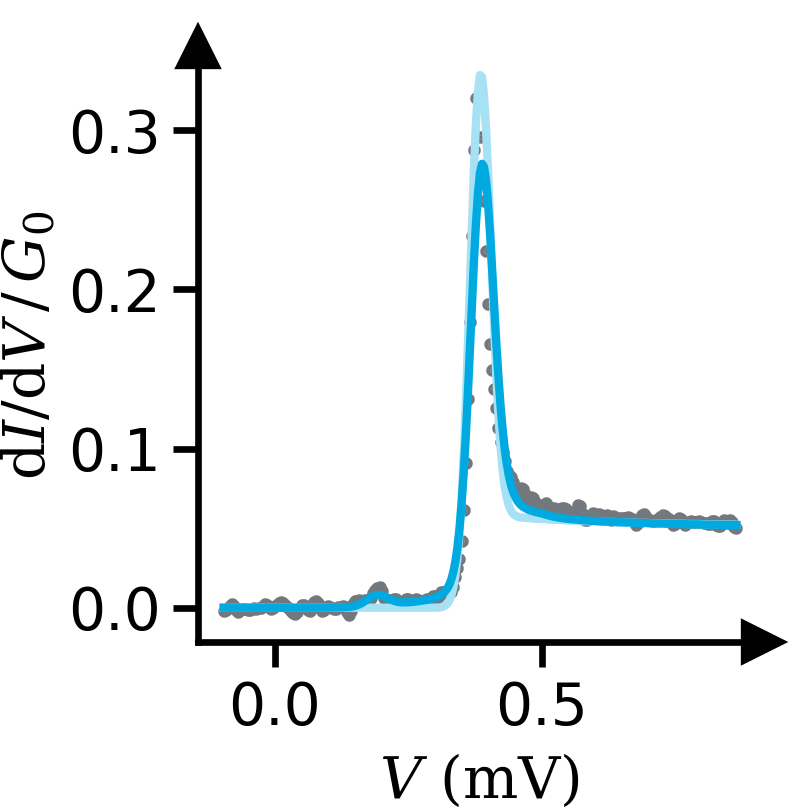

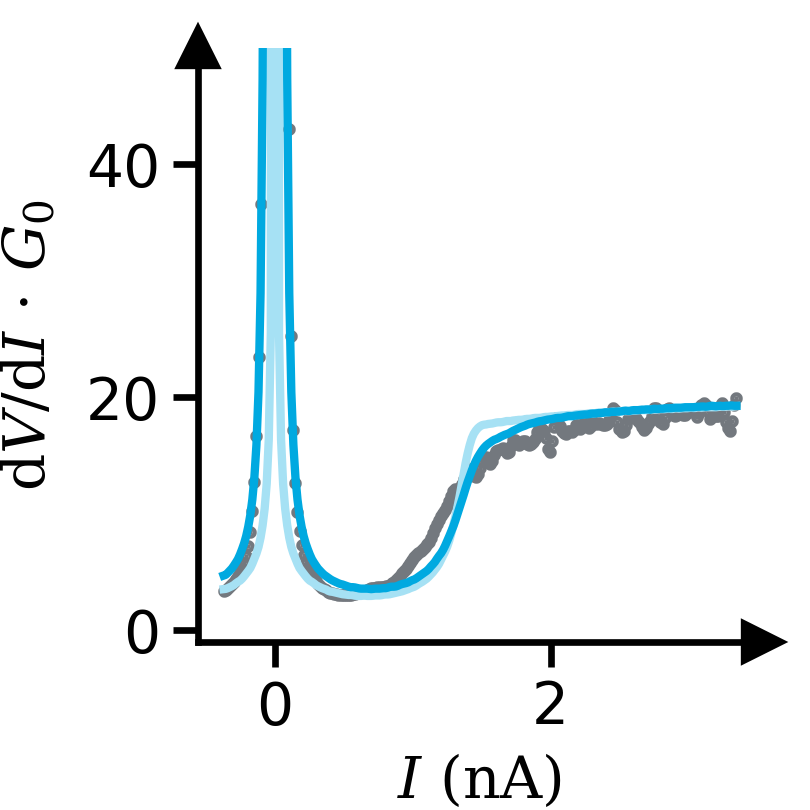

In [ ]:
# 0.05, single iv
from superconductivity.utilities.functions.upsampling import upsample
from superconductivity.utilities.functions.fill_nans import fill
from apply_sigmaV import apply_sigmaV

path = "0.05G0/15.0GHz_stripline"
data_exp = np.load(f"{path}/eva.npz")

Vbias_mV = data_exp["Vbias_mV"]
Ibias_nA = data_exp["Ibias_nA"]
Iexp_nA = data_exp["Iexp_nA"][0, :]
dGexp_G0 = data_exp["dGexp_G0"][0, :]
dRexp_R0 = data_exp["dRexp_R0"][0, :]

data_mar = np.load(f"{path}/mar_data.npz")
# Vbiasmar_mV = data_mar["V_mV"]
# Imar_nA = data_mar["Ifit_nA"]
Delta_meV = data_mar["Delta_meV"]
GN_G0 = 0.05
Imar_nA = sc.get_Imar_nA(
    V_mV=Vbias_mV,
    tau=[0.045, 0.001, 0.001, 0.001, 0.001, 0.001],
    Delta_meV=Delta_meV,
    T_K=0.0,
    gamma_meV=1e-6,
)
Imar_nA[np.logical_and(Vbias_mV <= 0.5, Vbias_mV >= 0.45)] = np.nan
Imar_nA = fill(Imar_nA)
Imar_nA = apply_sigmaV(V_mV=Vbias_mV, I_nA=Imar_nA, sigmaV_mV=0.0195)

data_mar = np.load(f"{path}/fit_pat.npz")
Vbiaspat_mV = data_mar["Vbias_mV"]
Ipat_nA = data_mar["Ifit_nA"][0, :]
Ibcs_nA = sc.get_Ibcs_nA(
    V_mV=Vbias_mV,
    GN_G0=GN_G0,
    T_K=0.0,
    gamma_meV=1e-6,
    Delta_meV=Delta_meV,
    sigmaV_mV=0.0195,
    backend="np",
    kernel="adaptive",
)

Vbias0_mV = np.linspace(-0.5, 4.5, 251) * Delta_meV
Ibias0_nA = np.linspace(-0.5, 4.5, 251) * Delta_meV * GN_G0 * sc.G0_muS
Iexp0_nA = sc.bin_y_over_x(upsample(Iexp_nA), upsample(Vbias_mV), Vbias0_mV)
Imar0_nA = sc.bin_y_over_x(upsample(Imar_nA), upsample(Vbias_mV), Vbias0_mV)
Ibcs0_nA = sc.bin_y_over_x(upsample(Ibcs_nA), upsample(Vbias_mV), Vbias0_mV)

dGexp0_G0 = np.gradient(Iexp0_nA, Vbias0_mV) / sc.G0_muS
dGmar0_G0 = np.gradient(Imar0_nA, Vbias0_mV) / sc.G0_muS
dGbcs0_G0 = np.gradient(Ibcs0_nA, Vbias0_mV) / sc.G0_muS

Vexp0_mV = sc.bin_y_over_x(upsample(Vbias_mV), upsample(Iexp_nA), Ibias0_nA)
Vmar0_mV = sc.bin_y_over_x(upsample(Vbias_mV), upsample(Imar_nA), Ibias0_nA)
Vbcs0_mV = sc.bin_y_over_x(upsample(Vbias_mV), upsample(Ibcs_nA), Ibias0_nA)

dRexp0_R0 = np.gradient(Vexp0_mV, Ibias0_nA) * sc.G0_muS
dRmar0_R0 = np.gradient(Vmar0_mV, Ibias0_nA) * sc.G0_muS
dRbcs0_R0 = np.gradient(Vbcs0_mV, Ibias0_nA) * sc.G0_muS

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias0_mV,
    Iexp0_nA,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-2,
)
ax.plot(
    Vbias0_mV,
    Imar0_nA,
    "-",
    color=sc.seeblau100,
    label="MAR fit",
    zorder=0,
)
ax.plot(
    Vbias0_mV,
    Ibcs0_nA,
    "-",
    color=sc.seeblau35,
    label="BCS ref.",
    zorder=-1,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.5)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias0_mV,
    dGexp0_G0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-2,
)
ax.plot(
    Vbias0_mV,
    dGmar0_G0,
    "-",
    color=sc.seeblau100,
    label="MAR fit",
    zorder=0,
)
ax.plot(
    Vbias0_mV,
    dGbcs0_G0,
    "-",
    color=sc.seeblau35,
    label="BCS fit",
    zorder=-1,
)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.5)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Ibias0_nA,
    dRexp0_R0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-2,
)
ax.plot(
    Ibias0_nA,
    dRmar0_R0,
    "-",
    color=sc.seeblau100,
    label="MAR fit",
    zorder=0,
)
ax.plot(
    Ibias0_nA,
    dRbcs0_R0,
    "-",
    color=sc.seeblau35,
    label="BCS fit",
    zorder=-1,
)
ax.set_ylim(-1, 50)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()